In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('/content/diabetes.csv')
print("Dataset loaded successfully!")

Dataset loaded successfully!


 Display the first and last few records

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


Determine the number of rows and columns

In [5]:
rows, columns = df.shape
print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 768
Number of columns: 9


 Identify numerical and categorical features, if present

In [6]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


Display data types

In [7]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


Generate descriptive statistics.


In [8]:
# There are no categorical columns in this dataset.
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Identify the target variable.

In [9]:
print("Target variable: Outcome")

print("\nTarget values:")
print(df['Outcome'].unique())

Target variable: Outcome

Target values:
[1 0]


Determine the number of samples in each target class

In [10]:
print(df['Outcome'].value_counts())
class_percentage = df['Outcome'].value_counts(normalize=True) * 100
print(class_percentage)

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


Class distribution

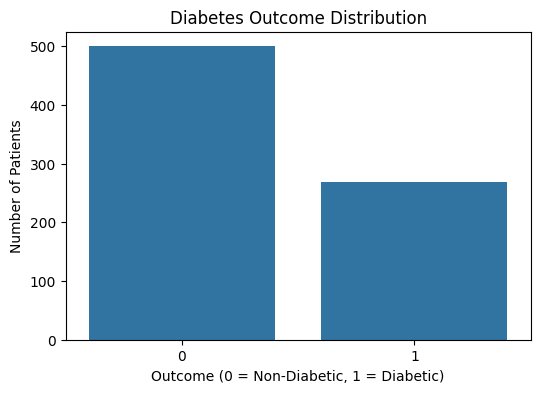

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Outcome')

plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Number of Patients')

plt.show()

 Prepare a brief description of each feature.
 | Feature                  | Data Type | Description                  | Role      |
| ------------------------ | --------- | ---------------------------- | --------- |
| Pregnancies              | Numerical | Number of pregnancies        | Predictor |
| Glucose                  | Numerical | Plasma glucose concentration | Predictor |
| BloodPressure            | Numerical | Diastolic blood pressure     | Predictor |
| SkinThickness            | Numerical | Triceps skin fold thickness  | Predictor |
| Insulin                  | Numerical | 2-Hour serum insulin         | Predictor |
| BMI                      | Numerical | Body Mass Index              | Predictor |
| DiabetesPedigreeFunction | Numerical | Diabetes pedigree function   | Predictor |
| Age                      | Numerical | Patient age                  | Predictor |
| Outcome                  | Binary    | Diabetes status              | Target    |


6.1 Univariate Analysis

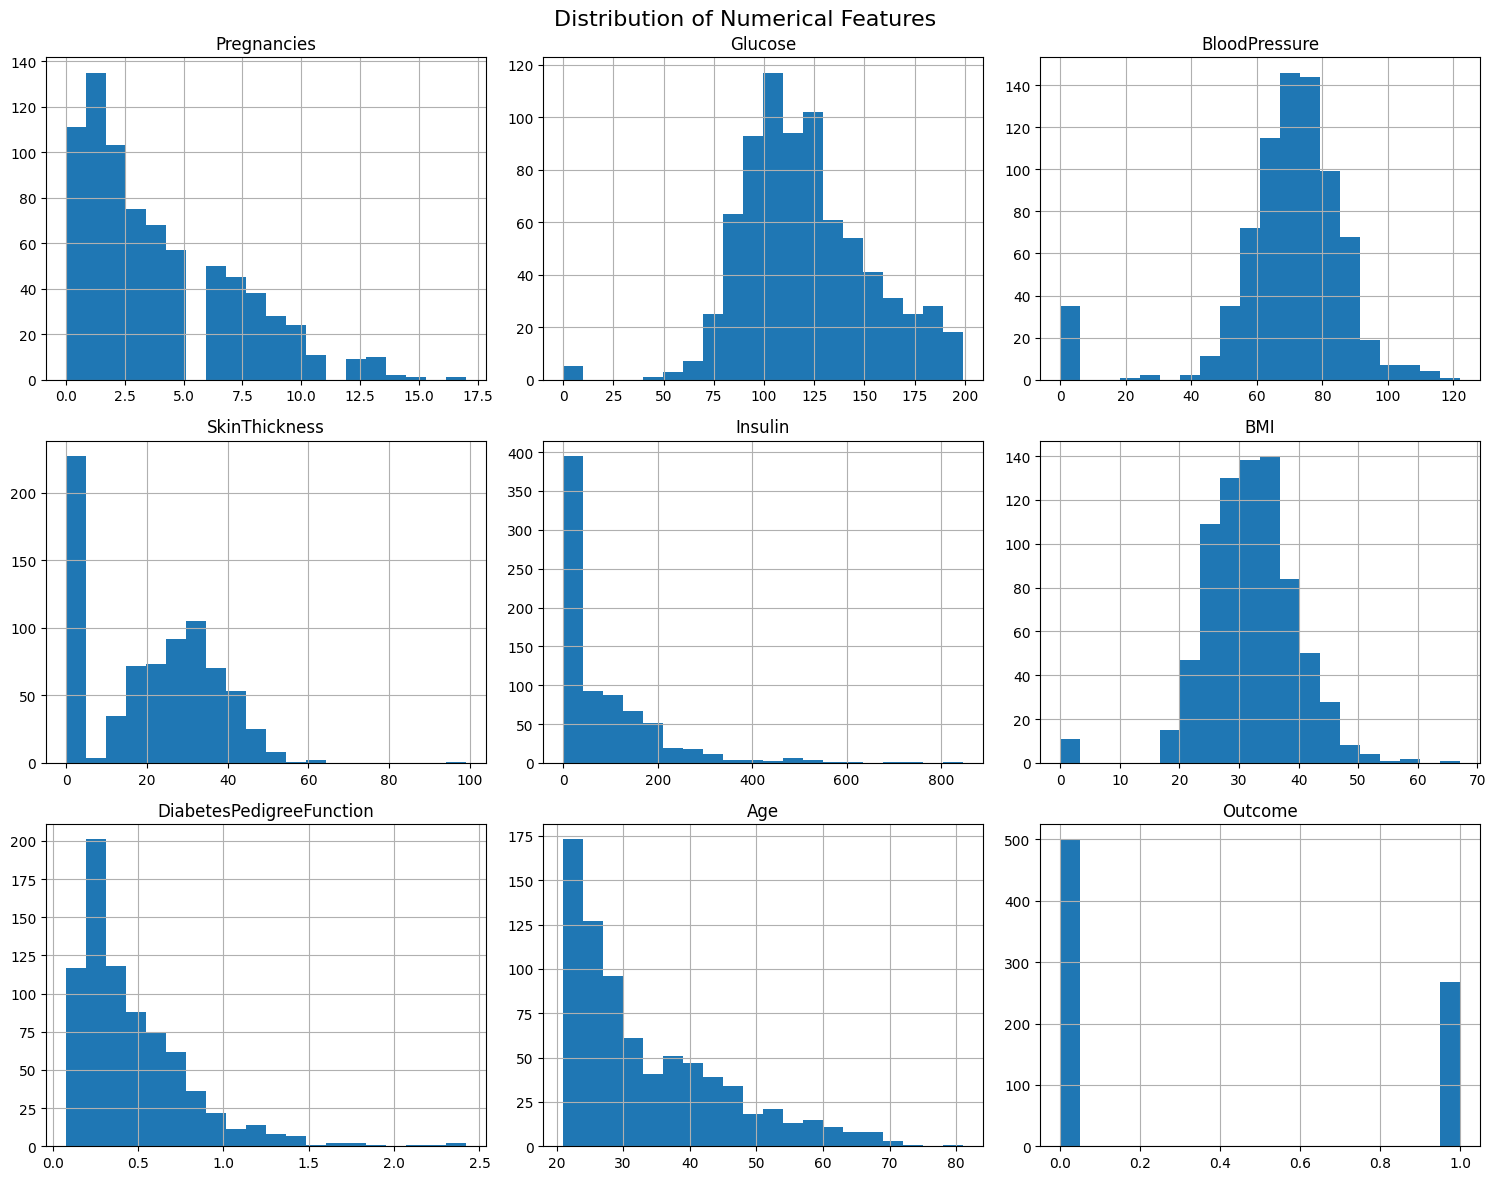

In [12]:
df.hist(figsize=(15, 12), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()
plt.show()

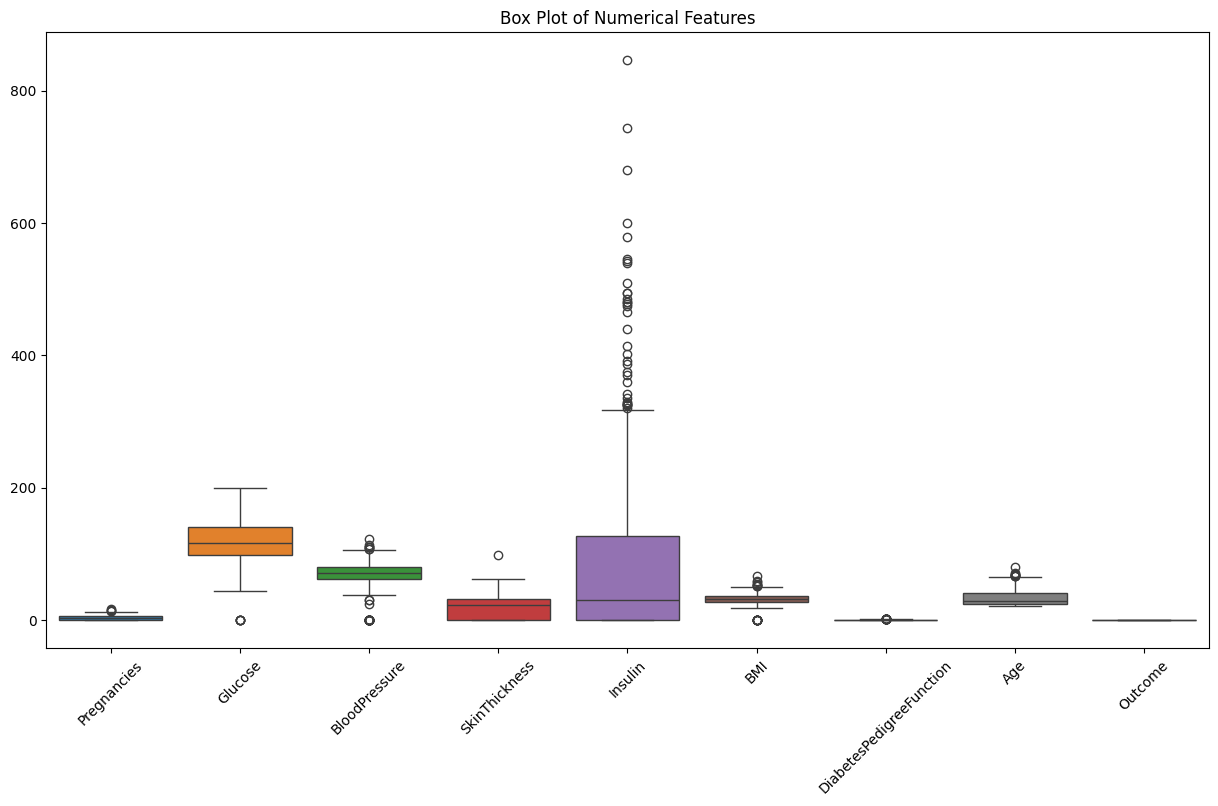

In [13]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df)

plt.title("Box Plot of Numerical Features")
plt.xticks(rotation=45)

plt.show()

In [14]:
skewness = df.skew(numeric_only=True)

print("Skewness of each feature:")
print(skewness)

Skewness of each feature:
Pregnancies                 0.901674
Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Outcome                     0.635017
dtype: float64


6.3 Bivariate Analysis

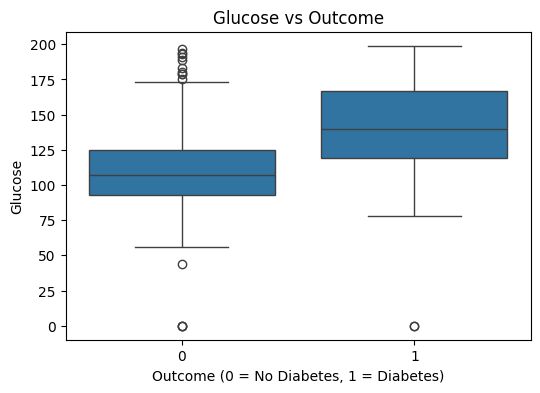

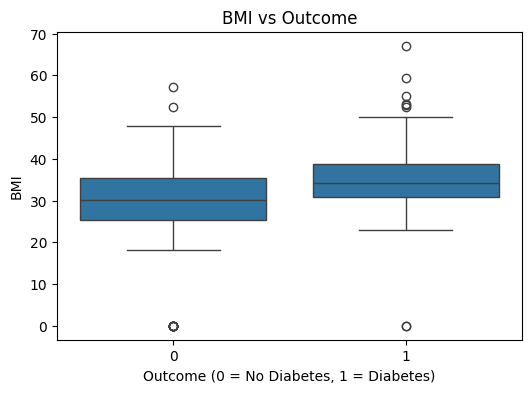

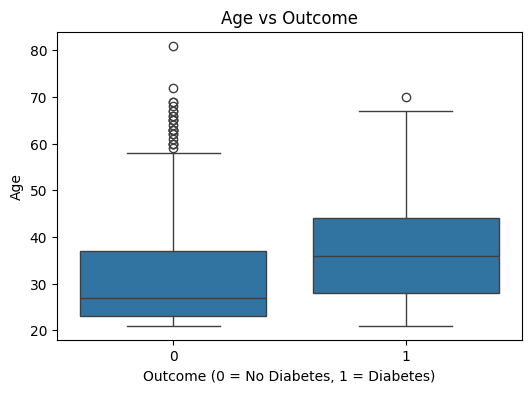

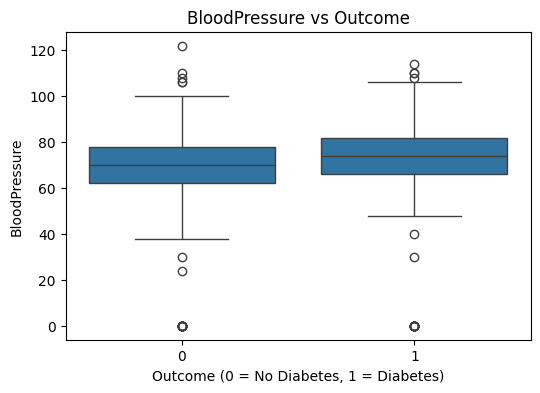

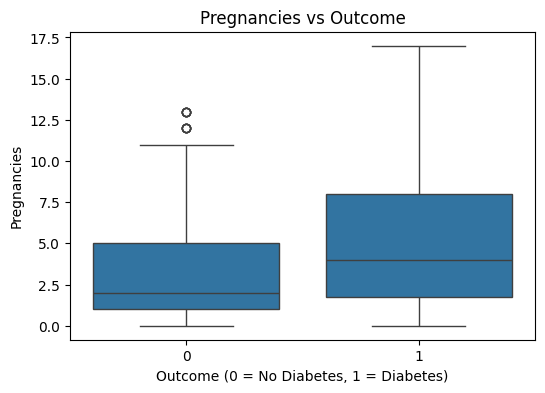

In [15]:
#  ☐ Box plots
features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Pregnancies']

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Outcome', y=feature, data=df)
    plt.title(f'{feature} vs Outcome')
    plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
    plt.ylabel(feature)
    plt.show()

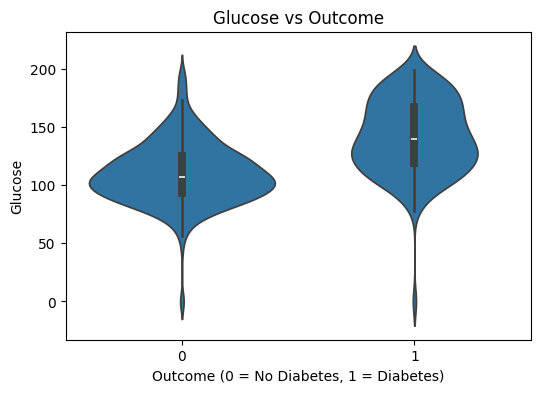

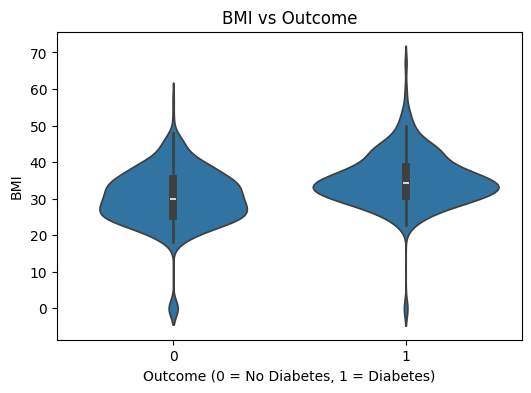

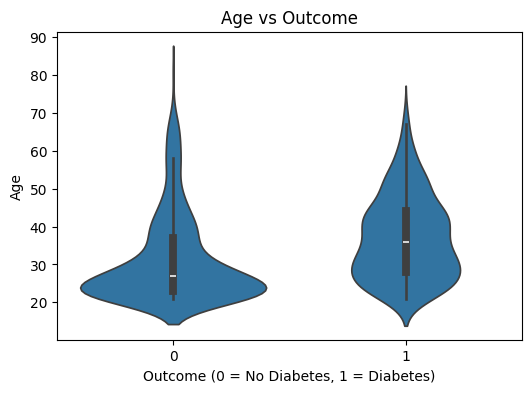

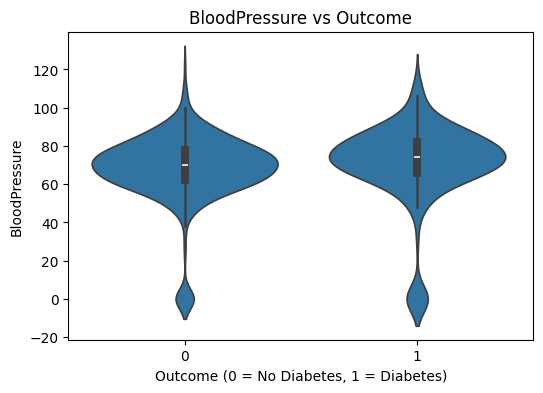

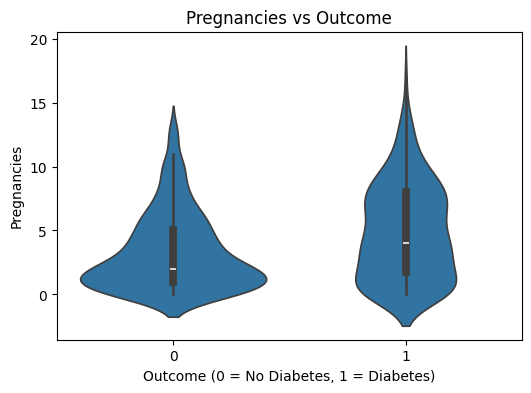

In [16]:
# Violin Plots
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.violinplot(x='Outcome', y=feature, data=df)
    plt.title(f'{feature} vs Outcome')
    plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
    plt.ylabel(feature)
    plt.show()

Scatter plots

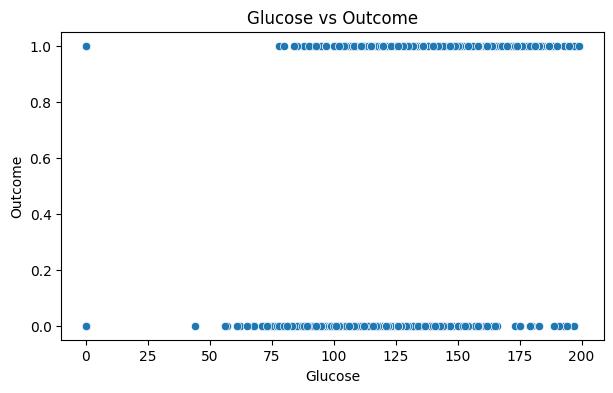

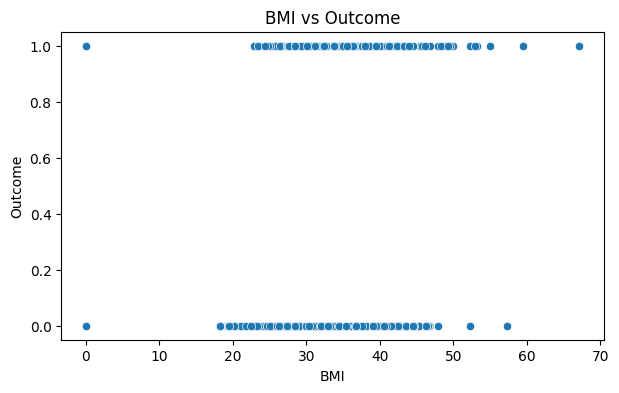

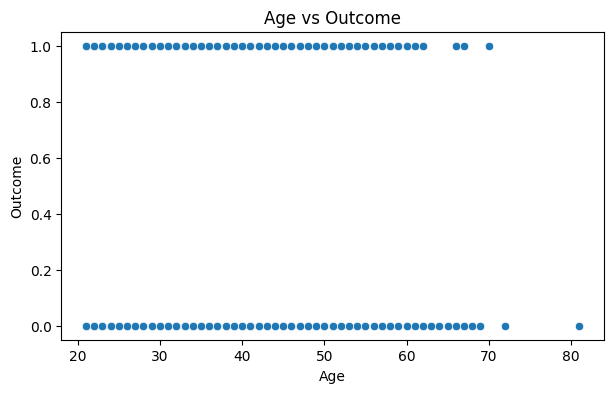

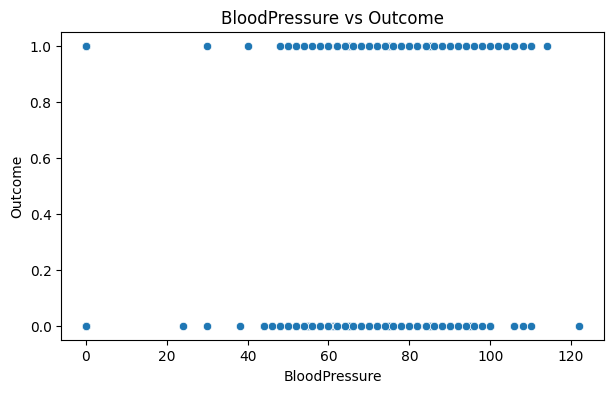

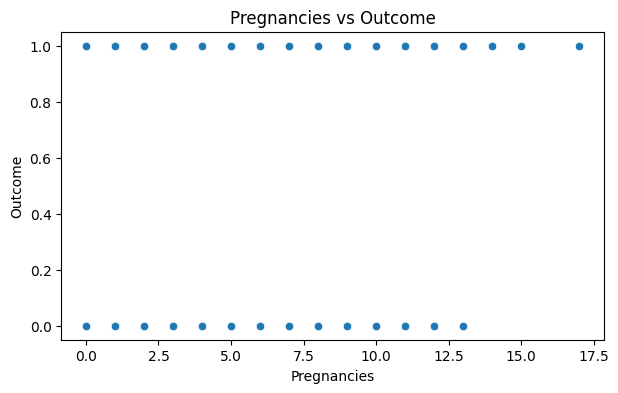

In [17]:
for feature in features:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(x=feature, y='Outcome', data=df)
    plt.title(f'{feature} vs Outcome')
    plt.xlabel(feature)
    plt.ylabel('Outcome')
    plt.show()

 ☐ Grouped statistics

In [18]:
grouped_stats = df.groupby('Outcome')[features].agg(['mean', 'median', 'std', 'min', 'max'])
print("Average values by diabetes outcome:\n")
grouped_stats

Average values by diabetes outcome:



Glucose                                   BMI                   \
               mean median        std min  max       mean median       std   
Outcome                                                                      
0        109.980000  107.0  26.141200   0  197  30.304200  30.05  7.689855   
1        141.257463  140.0  31.939622   0  199  35.142537  34.25  7.262967   

                    ... BloodPressure                            Pregnancies  \
         min   max  ...          mean median        std min  max        mean   
Outcome             ...                                                        
0        0.0  57.3  ...     68.184000   70.0  18.063075   0  122    3.298000   
1        0.0  67.1  ...     70.824627   74.0  21.491812   0  114    4.865672   

                                  
        median       std min max  
Outcome                           
0          2.0  3.017185   0  13  
1          4.0  3.741239   0  17  

[2 rows x 25 columns]

Correlation Analysis

☐ Generate a correlation matrix.

In [19]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


Create a heatmap

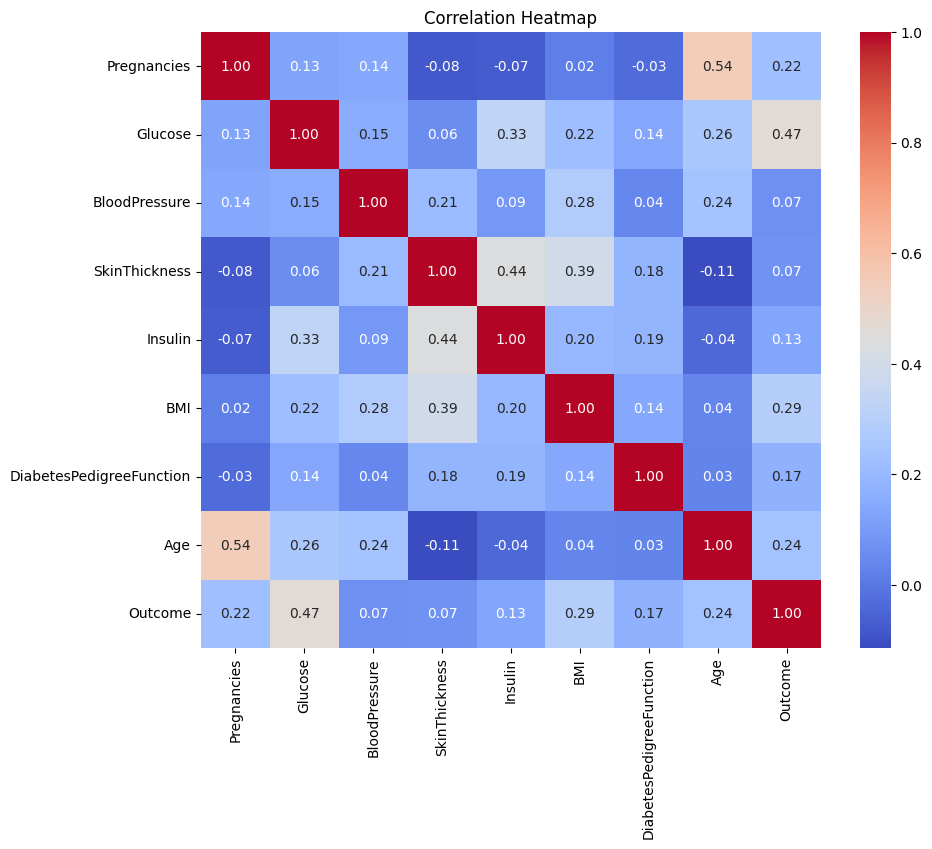

In [20]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

Identify strongly correlated features

In [21]:
for column in correlation_matrix.columns:
    for row in correlation_matrix.index:
        if column != row and abs(correlation_matrix.loc[row, column]) >= 0.5:
            print(
                row,
                "<->",
                column,
                ":",
                round(correlation_matrix.loc[row, column], 3)
            )

Age <-> Pregnancies : 0.544
Pregnancies <-> Age : 0.544


 Outlier Analysis

In [22]:
numeric_columns = df.select_dtypes(include=np.number).columns
for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_percentage = (outlier_count / len(df)) * 100

    print(
        f"{column}: {outlier_count} outliers "
        f"({outlier_percentage:.2f}%)"
    )

Pregnancies: 4 outliers (0.52%)
Glucose: 5 outliers (0.65%)
BloodPressure: 45 outliers (5.86%)
SkinThickness: 1 outliers (0.13%)
Insulin: 34 outliers (4.43%)
BMI: 19 outliers (2.47%)
DiabetesPedigreeFunction: 29 outliers (3.78%)
Age: 9 outliers (1.17%)
Outcome: 0 outliers (0.00%)


potential Z-score outliers

In [23]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df[numeric_columns]))

z_outliers = (z_scores > 3).sum(axis=0)

for column, count in zip(numeric_columns, z_outliers):
    print(column, ":", count, "potential Z-score outliers")

Pregnancies : 4 potential Z-score outliers
Glucose : 5 potential Z-score outliers
BloodPressure : 35 potential Z-score outliers
SkinThickness : 1 potential Z-score outliers
Insulin : 18 potential Z-score outliers
BMI : 14 potential Z-score outliers
DiabetesPedigreeFunction : 11 potential Z-score outliers
Age : 5 potential Z-score outliers
Outcome : 0 potential Z-score outliers


boxplot of outlier

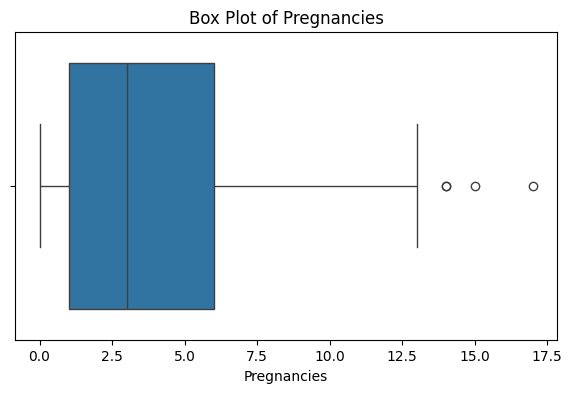

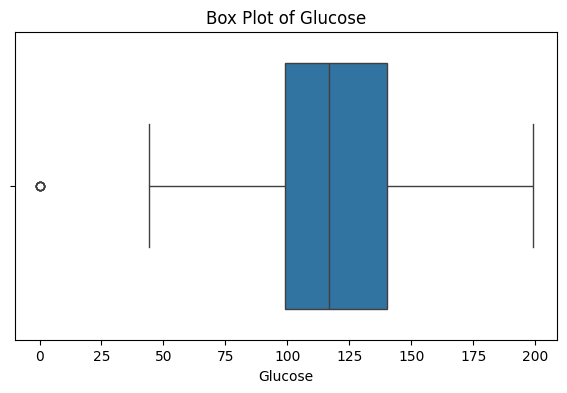

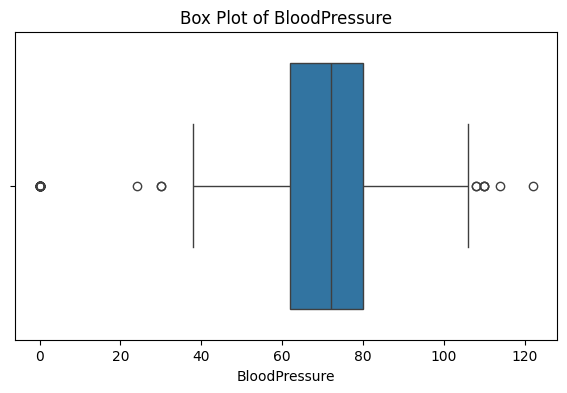

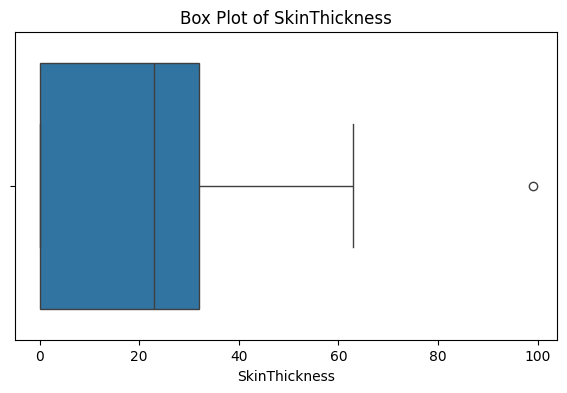

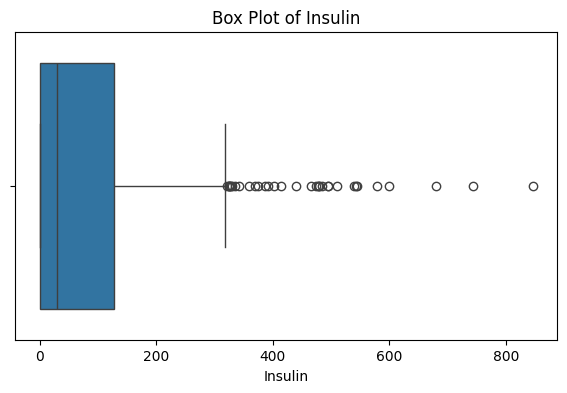

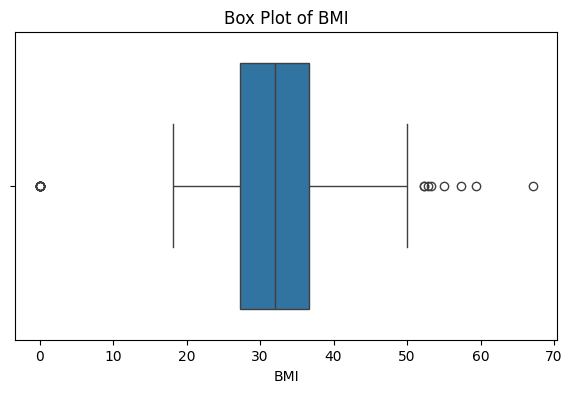

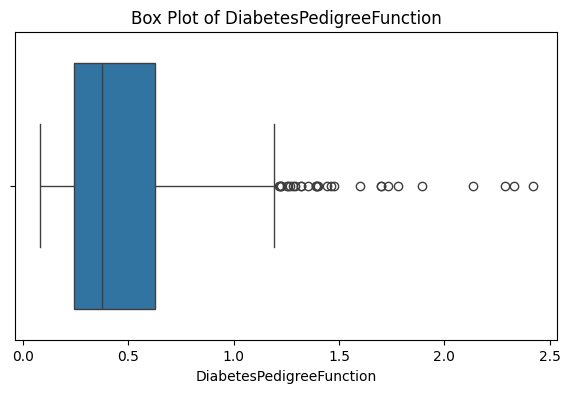

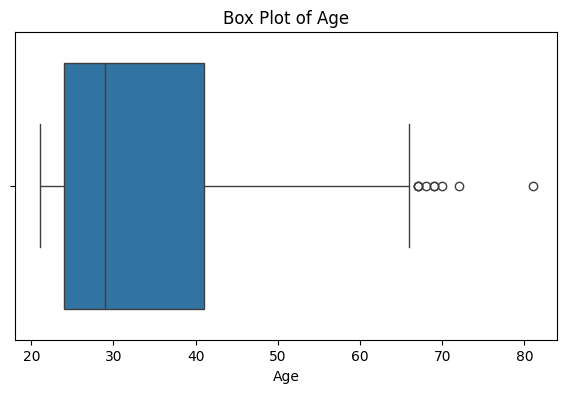

In [24]:
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for feature in features:

    plt.figure(figsize=(7, 4))

    sns.boxplot(x=df[feature])

    plt.title(f"Box Plot of {feature}")
    plt.xlabel(feature)

    plt.show()

In [25]:
zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

print("Median values used for preprocessing:")

for col in zero_columns:
    print(col, "=", df[col].median())

Median values used for preprocessing:
Glucose = 117.0
BloodPressure = 72.0
SkinThickness = 23.0
Insulin = 30.5
BMI = 32.0


Data Quality and Preprocessing

In [26]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [27]:
# Columns where 0 may be an invalid value
zero_check_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

print("Number of zero values:")
print(df[zero_check_columns].eq(0).sum())

Number of zero values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [28]:
import numpy as np

# Replace 0 with NaN in selected medical columns
df[zero_check_columns] = df[zero_check_columns].replace(0, np.nan)

print("Missing values after replacing invalid zeros:")
print(df.isnull().sum())

Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [29]:
# Fill missing values with median
for column in zero_check_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after median imputation:")
print(df.isnull().sum())

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [30]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


Separate features X and target y.

In [31]:
# Features
X = df.drop('Outcome', axis=1)

# Target
y = df['Outcome']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


dataset after preprocessing

In [32]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (768, 9)

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0


. Feature Engineering

In [33]:
# Create age groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 25, 40, 60, 100],
    labels=['Young', 'Adult', 'Middle_Age', 'Senior']
)

print(df[['Age', 'AgeGroup']].head(10))

   Age    AgeGroup
0   50  Middle_Age
1   31       Adult
2   32       Adult
3   21       Young
4   33       Adult
5   30       Adult
6   26       Adult
7   29       Adult
8   53  Middle_Age
9   54  Middle_Age


In [34]:
# Create BMI categories
df['BMICategory'] = pd.cut(
    df['BMI'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

print(df[['BMI', 'BMICategory']].head(10))

    BMI BMICategory
0  33.6       Obese
1  26.6  Overweight
2  23.3      Normal
3  28.1  Overweight
4  43.1       Obese
5  25.6  Overweight
6  31.0       Obese
7  35.3       Obese
8  30.5       Obese
9  32.3       Obese


In [35]:
# Create glucose categories
df['GlucoseCategory'] = pd.cut(
    df['Glucose'],
    bins=[0, 100, 126, 300],
    labels=['Normal', 'Prediabetic', 'High']
)

print(df[['Glucose', 'GlucoseCategory']].head(10))

   Glucose GlucoseCategory
0    148.0            High
1     85.0          Normal
2    183.0            High
3     89.0          Normal
4    137.0            High
5    116.0     Prediabetic
6     78.0          Normal
7    115.0     Prediabetic
8    197.0            High
9    125.0     Prediabetic


In [36]:
print(df.head())
print("\nNew shape:", df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome    AgeGroup BMICategory  \
0                     0.627   50        1  Middle_Age       Obese   
1                     0.351   31        0       Adult  Overweight   
2                     0.672   32        1       Adult      Normal   
3                     0.167   21        0       Young  Overweight   
4                     2.288   33        1       Adult       Obese   

  GlucoseCategory  
0            High  
1          Normal  
2            High  
3          Normal  
4            High  

New shape: (768, 12)


Create Feature Interactions

In [37]:
df['Glucose_BMI'] = df['Glucose'] * df['BMI']

In [38]:
df['Glucose_Age'] = df['Glucose'] * df['Age']

In [39]:
df['BMI_Age'] = df['BMI'] * df['Age']

In [40]:
print(df[['Glucose', 'BMI', 'Age',
          'Glucose_BMI', 'Glucose_Age', 'BMI_Age']].head())

   Glucose   BMI  Age  Glucose_BMI  Glucose_Age  BMI_Age
0    148.0  33.6   50       4972.8       7400.0   1680.0
1     85.0  26.6   31       2261.0       2635.0    824.6
2    183.0  23.3   32       4263.9       5856.0    745.6
3     89.0  28.1   21       2500.9       1869.0    590.1
4    137.0  43.1   33       5904.7       4521.0   1422.3


In [41]:
df.shape
# Original features       = 9
# Age/BMI/Glucose groups  = 3
# Interactions             = 3
# Total                    = 15

(768, 15)

In [42]:
print(df[['Glucose_BMI', 'Glucose_Age', 'BMI_Age', 'Outcome']].corr()['Outcome'])

Glucose_BMI    0.519906
Glucose_Age    0.410235
BMI_Age        0.362990
Outcome        1.000000
Name: Outcome, dtype: float64


In [43]:
# Log transformation of highly skewed variables
# Check skewness
features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

print(df[features].skew().sort_values(ascending=False))

Insulin                     3.380019
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Pregnancies                 0.901674
SkinThickness               0.837608
BMI                         0.599233
Glucose                     0.535587
BloodPressure               0.141885
dtype: float64


In [44]:
import numpy as np

df['Insulin_Log'] = np.log1p(df['Insulin'])
df['DiabetesPedigreeFunction_Log'] = np.log1p(df['DiabetesPedigreeFunction'])

In [45]:
print("Original Insulin skewness:",
      df['Insulin'].skew())

print("Log Insulin skewness:",
      df['Insulin_Log'].skew())

print("Original DiabetesPedigreeFunction skewness:",
      df['DiabetesPedigreeFunction'].skew())

print("Log DiabetesPedigreeFunction skewness:",
      df['DiabetesPedigreeFunction_Log'].skew())

Original Insulin skewness: 3.380019128212173
Log Insulin skewness: -0.17507805732972928
Original DiabetesPedigreeFunction skewness: 1.919911066307204
Log DiabetesPedigreeFunction skewness: 1.1179417116303714


In [46]:
#  Feature selection based on correlation or model importance
# Correlation of numerical features with Outcome
correlation = df[features + ['Outcome']].corr()['Outcome'].sort_values(ascending=False)

print(correlation)

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.214873
Insulin                     0.203790
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Name: Outcome, dtype: float64


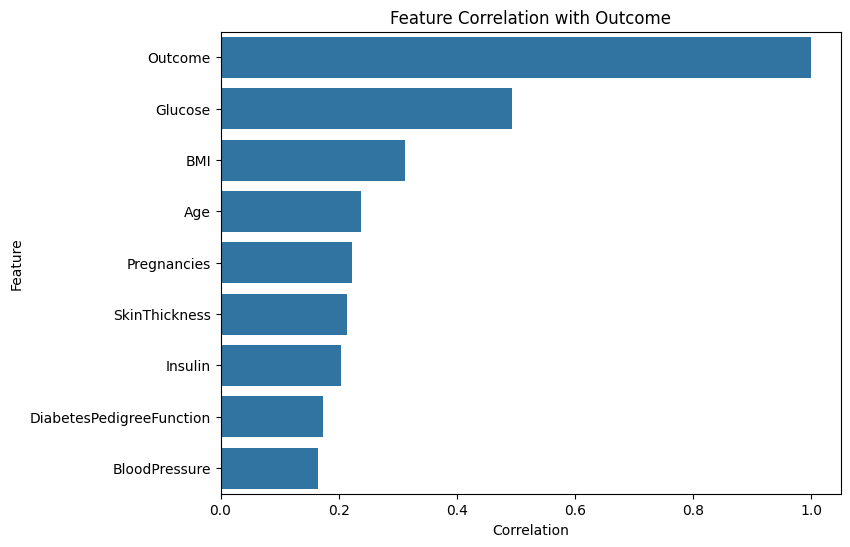

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=correlation.values, y=correlation.index)

plt.title("Feature Correlation with Outcome")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

In [48]:
from sklearn.ensemble import RandomForestClassifier

# Use original numerical features
X_temp = df[features]
y_temp = df['Outcome']

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_temp, y_temp)

importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

Glucose                     0.263715
BMI                         0.167470
Age                         0.127208
DiabetesPedigreeFunction    0.124075
Insulin                     0.084843
BloodPressure               0.082722
Pregnancies                 0.079268
SkinThickness               0.070699
dtype: float64


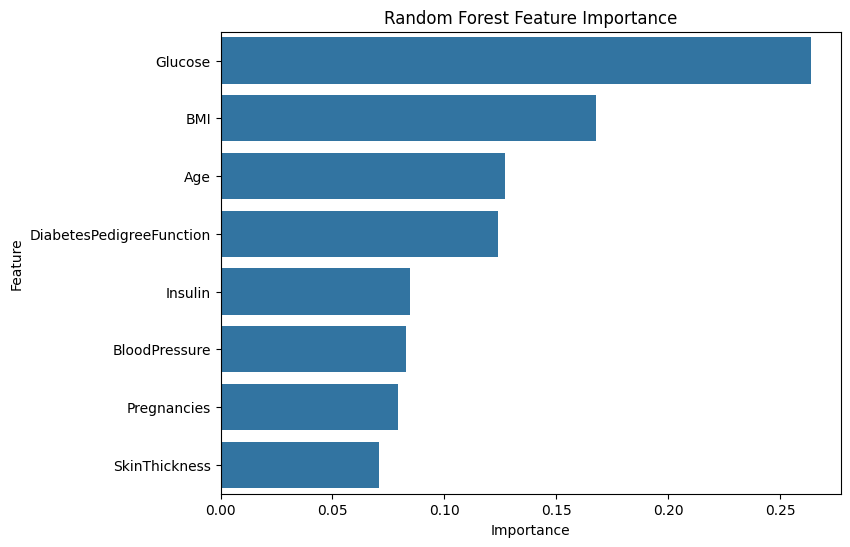

In [49]:
plt.figure(figsize=(8, 6))

sns.barplot(
    x=importance.values,
    y=importance.index
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

**Train-Test Split**

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Numerical features to use for the model
model_features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Glucose_BMI',
    'Glucose_Age',
    'BMI_Age',
    'Insulin_Log',
    'DiabetesPedigreeFunction_Log'
]

X = df[model_features]
y = df['Outcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Training data: (614, 13)
Testing data: (154, 13)
Scaling completed successfully!


In [51]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

print("Minimum values:")
print(X_train_minmax.min(axis=0))

print("\nMaximum values:")
print(X_train_minmax.max(axis=0))

Minimum values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Maximum values:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [52]:
# For this project, we'll select StandardScaler for the MLP.
# Without scaling, features with larger numerical values can have an unnecessarily
# large influence on the learning process.

# Scaling puts the features on a comparable numerical scale, which generally helps
# the MLP train more effectively and makes optimization more stable.

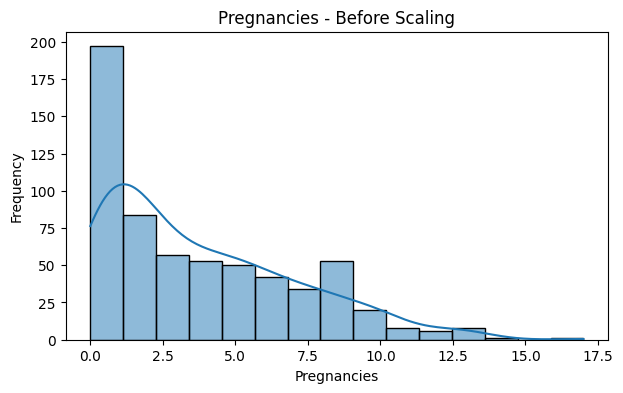

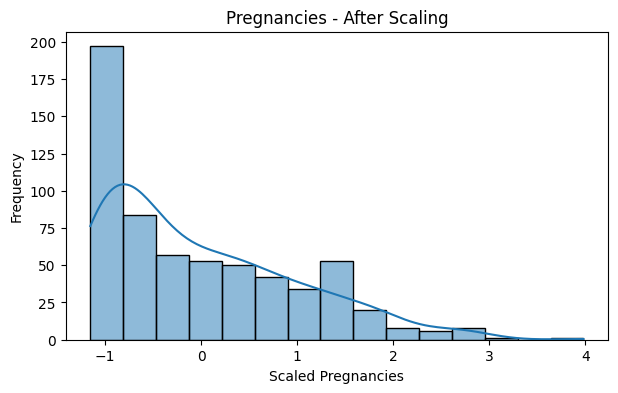

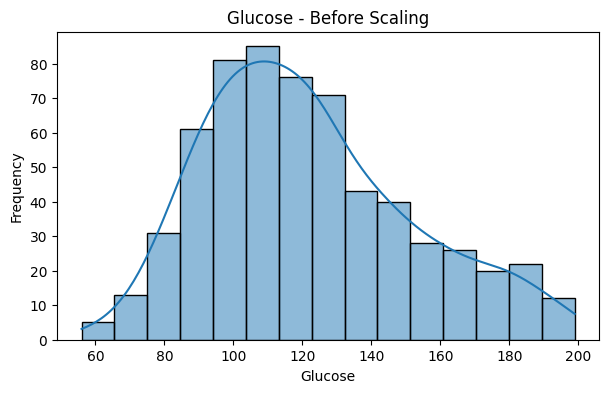

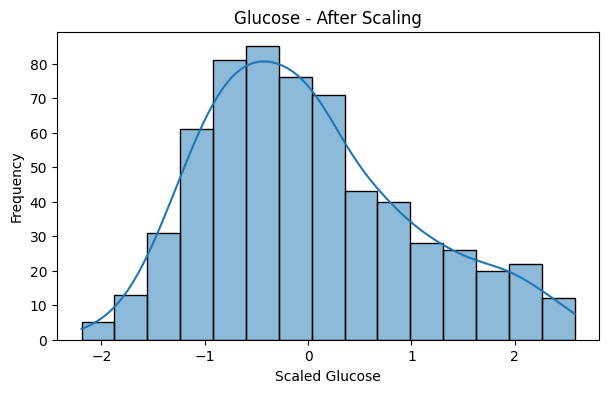

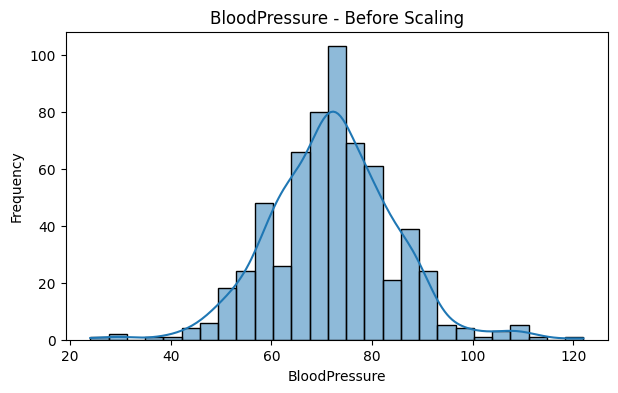

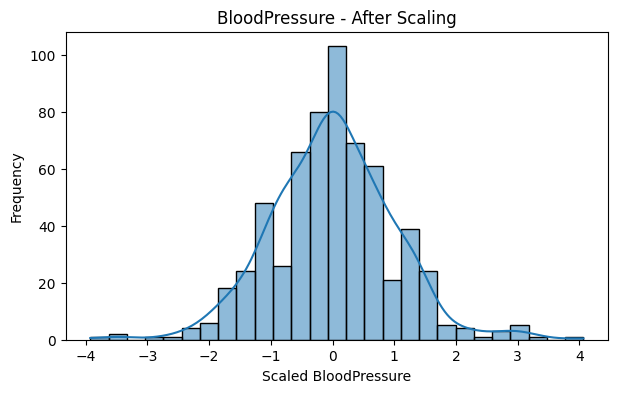

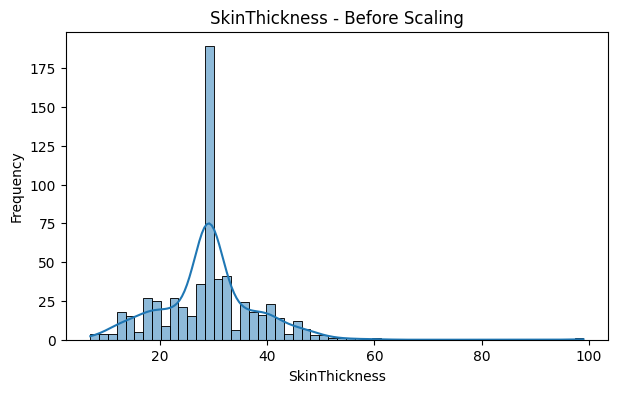

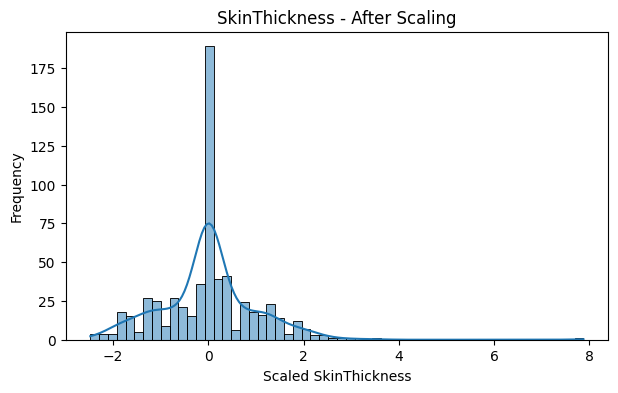

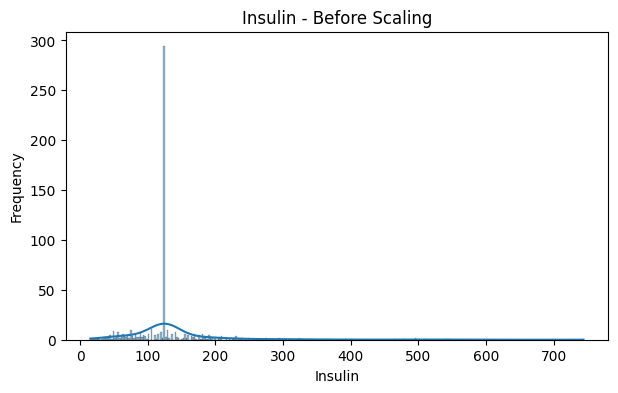

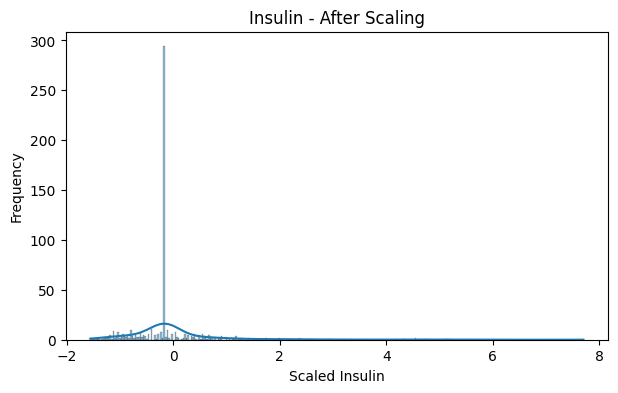

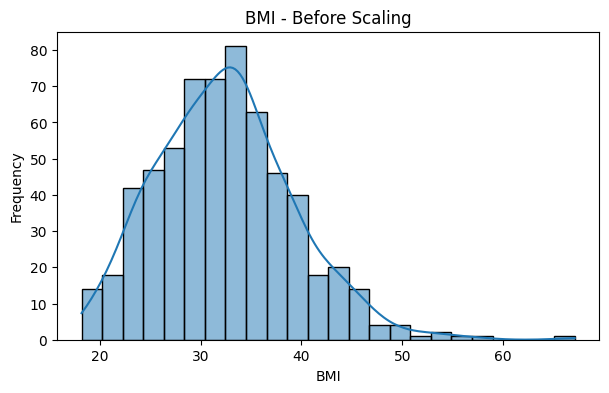

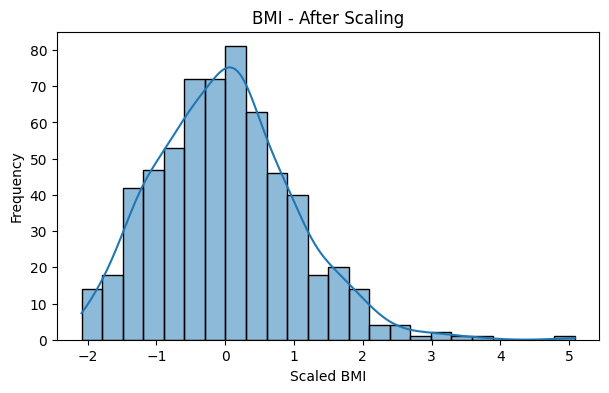

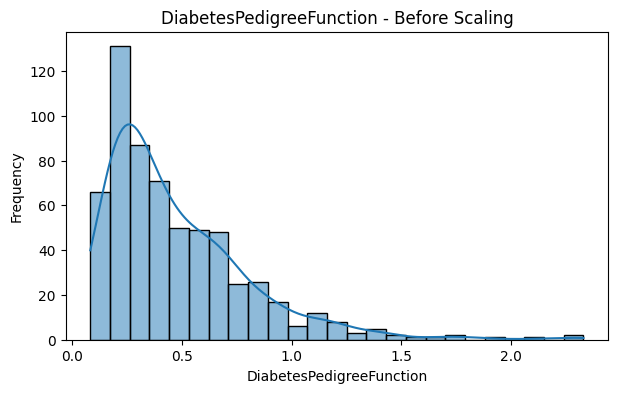

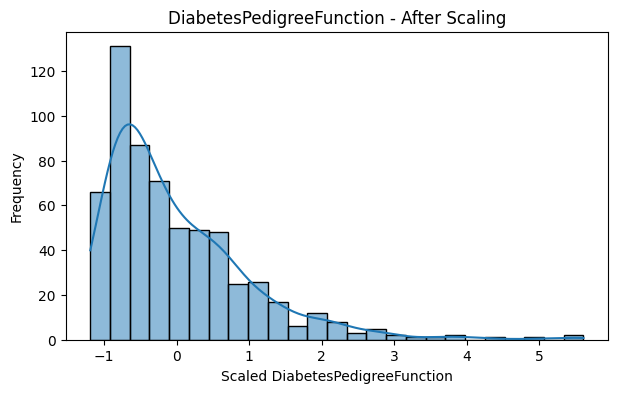

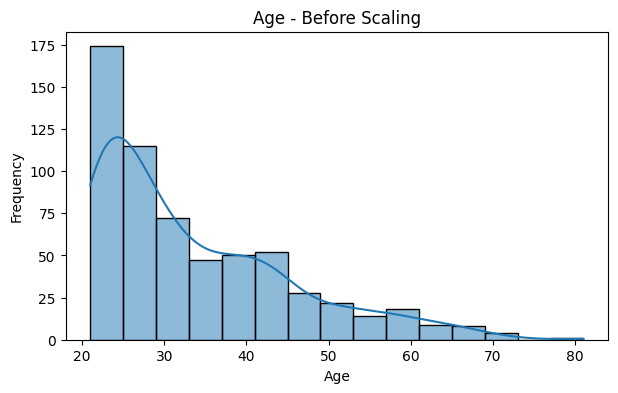

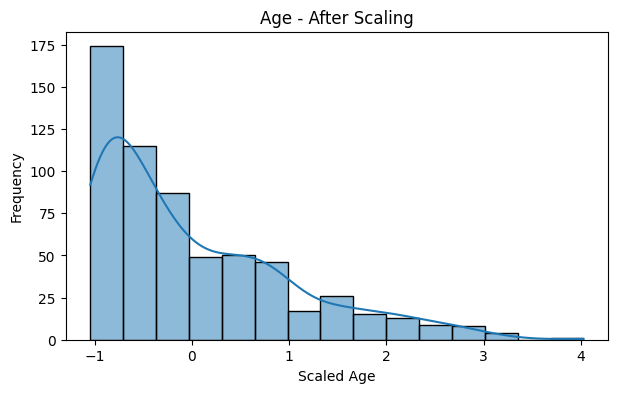

In [53]:
# Convert scaled data into DataFrame
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

features = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

# Compare before and after scaling
for feature in features:

    # Before scaling
    plt.figure(figsize=(7, 4))
    sns.histplot(X_train[feature], kde=True)
    plt.title(f"{feature} - Before Scaling")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

    # After scaling
    plt.figure(figsize=(7, 4))
    sns.histplot(X_train_scaled_df[feature], kde=True)
    plt.title(f"{feature} - After Scaling")
    plt.xlabel(f"Scaled {feature}")
    plt.ylabel("Frequency")
    plt.show()

Baseline and Multiple Model Development

In [54]:
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

Logistic Regression

In [55]:
# A. Create the model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [56]:
# B. Train the model and record training time
start_time = time.time()

logistic_model.fit(X_train_scaled, y_train)

logistic_training_time = time.time() - start_time

print("Training time:", logistic_training_time, "seconds")

Training time: 0.017191648483276367 seconds


In [57]:
# C. Generate predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)

y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [58]:
# D. Calculate evaluation metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_roc_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression Results")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)
print("ROC-AUC  :", logistic_roc_auc)

Logistic Regression Results
Accuracy : 0.6883116883116883
Precision: 0.5652173913043478
Recall   : 0.48148148148148145
F1 Score : 0.52
ROC-AUC  : 0.8096296296296296


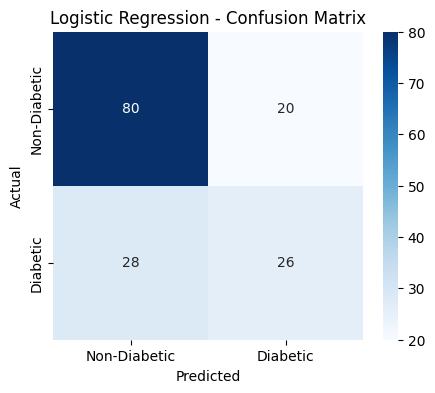

In [59]:
# E. Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

K-Nearest Neighbors (KNN)

In [60]:
# A. Create model
knn_model = KNeighborsClassifier(n_neighbors=5)

In [61]:
# B. Train and record time
start_time = time.time()

knn_model.fit(X_train_scaled, y_train)

knn_training_time = time.time() - start_time

print("Training time:", knn_training_time, "seconds")

Training time: 0.005598783493041992 seconds


In [62]:
# C. Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

In [63]:
# D. Metrics
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_roc_auc = roc_auc_score(y_test, y_prob_knn)

print("KNN Results")
print("Accuracy :", knn_accuracy)
print("Precision:", knn_precision)
print("Recall   :", knn_recall)
print("F1 Score :", knn_f1)
print("ROC-AUC  :", knn_roc_auc)

KNN Results
Accuracy : 0.7402597402597403
Precision: 0.6346153846153846
Recall   : 0.6111111111111112
F1 Score : 0.6226415094339622
ROC-AUC  : 0.7831481481481481


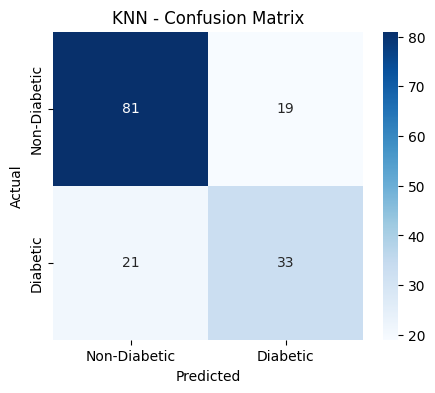

In [64]:
# E. Confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Support Vector Machine (SVM)

In [65]:
# A. Create model
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

In [66]:
# B. Train
start_time = time.time()

svm_model.fit(X_train_scaled, y_train)

svm_training_time = time.time() - start_time

print("Training time:", svm_training_time, "seconds")

Training time: 0.06480860710144043 seconds


In [67]:
# C. Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

In [68]:
# D. Metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_roc_auc = roc_auc_score(y_test, y_prob_svm)

print("SVM Results")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)
print("ROC-AUC  :", svm_roc_auc)

SVM Results
Accuracy : 0.7337662337662337
Precision: 0.6511627906976745
Recall   : 0.5185185185185185
F1 Score : 0.5773195876288659
ROC-AUC  : 0.7994444444444444


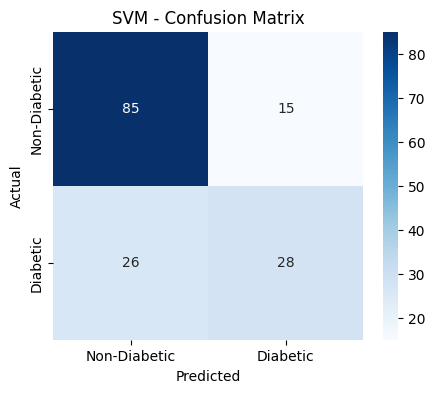

In [69]:
# E. Confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest

In [70]:
# A. Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [71]:
# Train
start_time = time.time()

rf_model.fit(X_train_scaled, y_train)

rf_training_time = time.time() - start_time

print("Training time:", rf_training_time, "seconds")

Training time: 0.26895618438720703 seconds


In [72]:
# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

In [73]:
# Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest Results
Accuracy : 0.7272727272727273
Precision: 0.6304347826086957
Recall   : 0.5370370370370371
F1 Score : 0.58
ROC-AUC  : 0.8272222222222222


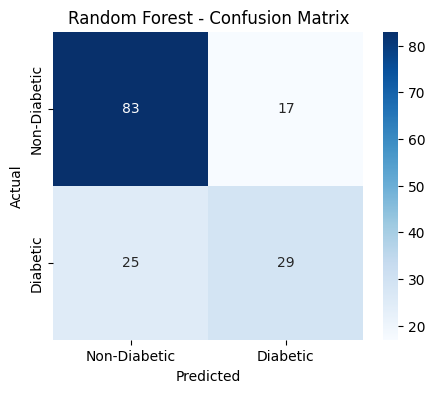

In [74]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Create One Comparison Table

In [75]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Random Forest'
    ],
    'Accuracy': [
        logistic_accuracy,
        knn_accuracy,
        svm_accuracy,
        rf_accuracy
    ],
    'Precision': [
        logistic_precision,
        knn_precision,
        svm_precision,
        rf_precision
    ],
    'Recall': [
        logistic_recall,
        knn_recall,
        svm_recall,
        rf_recall
    ],
    'F1 Score': [
        logistic_f1,
        knn_f1,
        svm_f1,
        rf_f1
    ],
    'ROC-AUC': [
        logistic_roc_auc,
        knn_roc_auc,
        svm_roc_auc,
        rf_roc_auc
    ],
    'Training Time (sec)': [
        logistic_training_time,
        knn_training_time,
        svm_training_time,
        rf_training_time
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC  \
0  Logistic Regression  0.688312   0.565217  0.481481  0.520000  0.809630   
1                  KNN  0.740260   0.634615  0.611111  0.622642  0.783148   
2                  SVM  0.733766   0.651163  0.518519  0.577320  0.799444   
3        Random Forest  0.727273   0.630435  0.537037  0.580000  0.827222   

   Training Time (sec)  
0             0.017192  
1             0.005599  
2             0.064809  
3             0.268956  


MLP Model

In [76]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
tf.random.set_seed(42)

Create the MLP architecture

In [77]:
# Create the MLP architecture
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
mlp_model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [79]:
# Train the MLP
start_time = time.time()

history = mlp_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

mlp_training_time = time.time() - start_time

print("MLP Training Time:", mlp_training_time, "seconds")

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6884 - loss: 0.5797 - val_accuracy: 0.7236 - val_loss: 0.5208
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7454 - loss: 0.5007 - val_accuracy: 0.7480 - val_loss: 0.4794
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7536 - loss: 0.4697 - val_accuracy: 0.7561 - val_loss: 0.4619
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7719 - loss: 0.4544 - val_accuracy: 0.7642 - val_loss: 0.4520
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7882 - loss: 0.4446 - val_accuracy: 0.7805 - val_loss: 0.4447
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7841 - loss: 0.4369 - val_accuracy: 0.7967 - val_loss: 0.4388
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7800 - loss: 0.4307 - val_accuracy: 0.7967 - val_loss: 0.4346
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7800 - loss: 0.4255 - val_accuracy: 0.7967 - 

In [80]:
print("Training completed.")
print("Final training accuracy:", history.history['accuracy'][-1])
print("Final validation accuracy:", history.history['val_accuracy'][-1])

Training completed.
Final training accuracy: 0.9348269104957581
Final validation accuracy: 0.7560975551605225


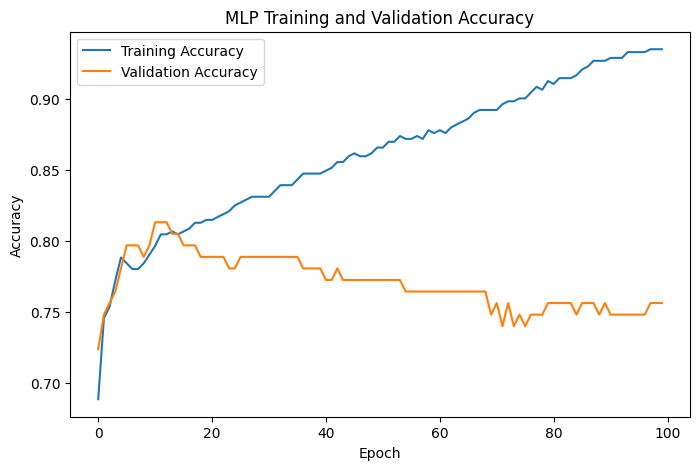

In [81]:
# plot Training & Validation Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('MLP Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

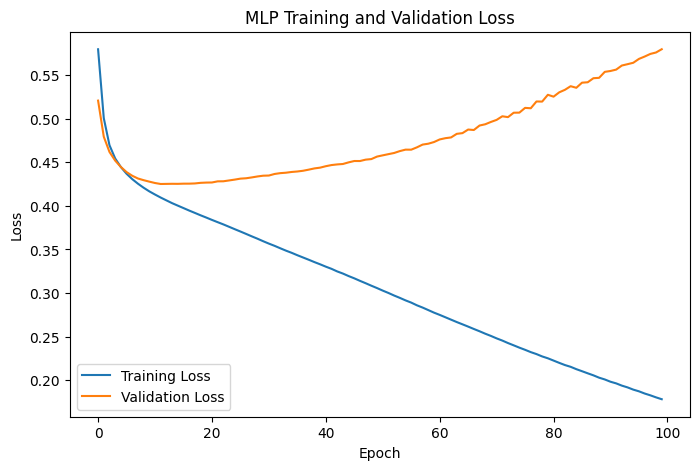

In [82]:
# Plot Training and Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('MLP Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [83]:
# Make predictions on the test data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict probabilities
y_prob_mlp = mlp_model.predict(X_test_scaled).ravel()

# Convert probabilities to 0 or 1
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_mlp)
precision = precision_score(y_test, y_pred_mlp)
recall = recall_score(y_test, y_pred_mlp)
f1 = f1_score(y_test, y_pred_mlp)
roc_auc = roc_auc_score(y_test, y_prob_mlp)

print("MLP Test Results")
print("----------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
MLP Test Results
----------------
Accuracy : 0.7272727272727273
Precision: 0.62
Recall   : 0.5740740740740741
F1 Score : 0.5961538461538461
ROC-AUC  : 0.8109259259259259


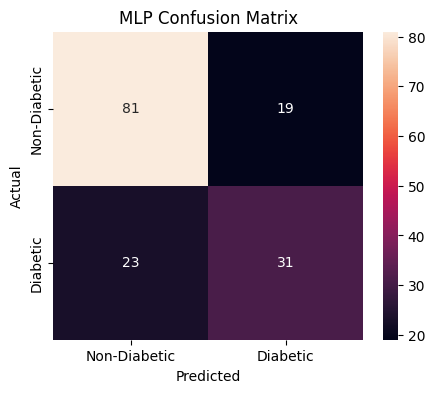

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [85]:
# Calculate the confusion-matrix values
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 81
False Positives: 19
False Negatives: 23
True Positives  : 31


Model Training

In [86]:
# Record Training and Validation Performance
print("Final Training Accuracy   :", history.history['accuracy'][-1])
print("Final Validation Accuracy :", history.history['val_accuracy'][-1])

print("Final Training Loss       :", history.history['loss'][-1])
print("Final Validation Loss     :", history.history['val_loss'][-1])

Final Training Accuracy   : 0.9348269104957581
Final Validation Accuracy : 0.7560975551605225
Final Training Loss       : 0.17819960415363312
Final Validation Loss     : 0.5797498822212219


In [87]:
import numpy as np

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_accuracy = max(history.history['val_accuracy'])

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val_accuracy)

Best Epoch: 11
Best Validation Accuracy: 0.8130081295967102


In [88]:
from tensorflow.keras.layers import Dropout

tf.random.set_seed(42)

dropout_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

dropout_model.summary()
dropout_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
dropout_history = dropout_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6171 - loss: 0.6635 - val_accuracy: 0.7236 - val_loss: 0.5372
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7352 - loss: 0.5484 - val_accuracy: 0.7642 - val_loss: 0.4846
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7169 - loss: 0.5047 - val_accuracy: 0.7805 - val_loss: 0.4568
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7352 - loss: 0.5105 - val_accuracy: 0.7886 - val_loss: 0.4485
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7556 - loss: 0.4824 - val_accuracy: 0.7967 - val_loss: 0.4448
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7739 - loss: 0.4777 - val_accuracy: 0.7967 - val_loss: 0.4424
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7617 - loss: 0.4652 - val_accuracy: 0.7967 - val_loss: 0.4430
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7719 - loss: 0.4398 - val_accuracy: 0.8049 - 

L2 Regularization

In [89]:
from tensorflow.keras.regularizers import l2
tf.random.set_seed(42)

l2_model = Sequential([
    Dense(
        64,
        activation='relu',
        kernel_regularizer=l2(0.001),
        input_shape=(X_train_scaled.shape[1],)
    ),

    Dense(
        32,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),

    Dense(1, activation='sigmoid')
])

l2_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
l2_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
l2_history = l2_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6599 - loss: 0.6816 - val_accuracy: 0.7480 - val_loss: 0.6020
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7271 - loss: 0.5851 - val_accuracy: 0.7642 - val_loss: 0.5439
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7597 - loss: 0.5444 - val_accuracy: 0.7805 - val_loss: 0.5209
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7658 - loss: 0.5246 - val_accuracy: 0.7805 - val_loss: 0.5095
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7780 - loss: 0.5114 - val_accuracy: 0.7886 - val_loss: 0.5016
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7902 - loss: 0.5012 - val_accuracy: 0.7886 - val_loss: 0.4952
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7882 - loss: 0.4931 - val_accuracy: 0.7967 - val_loss: 0.4904
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7902 - loss: 0.4865 - val_accuracy: 0.7967 - 

In [91]:
print("Final Training Accuracy   :", l2_history.history['accuracy'][-1])
print("Final Validation Accuracy :", l2_history.history['val_accuracy'][-1])
print("Final Training Loss       :", l2_history.history['loss'][-1])
print("Final Validation Loss     :", l2_history.history['val_loss'][-1])

Final Training Accuracy   : 0.9164969325065613
Final Validation Accuracy : 0.7642276287078857
Final Training Loss       : 0.2808838188648224
Final Validation Loss     : 0.5651373267173767


Early Stopping

In [92]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
tf.random.set_seed(42)

early_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
early_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [93]:
early_history = early_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6965 - loss: 0.6033 - val_accuracy: 0.7724 - val_loss: 0.5431
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7678 - loss: 0.5140 - val_accuracy: 0.7561 - val_loss: 0.4830
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7780 - loss: 0.4707 - val_accuracy: 0.7561 - val_loss: 0.4607
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7821 - loss: 0.4521 - val_accuracy: 0.7805 - val_loss: 0.4520
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7862 - loss: 0.4426 - val_accuracy: 0.7805 - val_loss: 0.4461
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7923 - loss: 0.4358 - val_accuracy: 0.7805 - val_loss: 0.4416
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7943 - loss: 0.4301 - val_accuracy: 0.7886 - val_loss: 0.4377
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7963 - loss: 0.4251 - val_accuracy: 0.

In [94]:
print("Epochs actually completed:", len(early_history.history['loss']))

print("Final Training Accuracy   :", early_history.history['accuracy'][-1])
print("Final Validation Accuracy :", early_history.history['val_accuracy'][-1])
print("Final Training Loss       :", early_history.history['loss'][-1])
print("Final Validation Loss     :", early_history.history['val_loss'][-1])

Epochs actually completed: 29
Final Training Accuracy   : 0.837067186832428
Final Validation Accuracy : 0.7804877758026123
Final Training Loss       : 0.3618597984313965
Final Validation Loss     : 0.4354867935180664


Compare the Regularization Techniques

In [95]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Original MLP',
        'Dropout',
        'L2 Regularization',
        'Early Stopping'
    ],
    'Final Training Accuracy': [
        history.history['accuracy'][-1],
        dropout_history.history['accuracy'][-1],
        l2_history.history['accuracy'][-1],
        early_history.history['accuracy'][-1]
    ],
    'Final Validation Accuracy': [
        history.history['val_accuracy'][-1],
        dropout_history.history['val_accuracy'][-1],
        l2_history.history['val_accuracy'][-1],
        early_history.history['val_accuracy'][-1]
    ],
    'Final Training Loss': [
        history.history['loss'][-1],
        dropout_history.history['loss'][-1],
        l2_history.history['loss'][-1],
        early_history.history['loss'][-1]
    ],
    'Final Validation Loss': [
        history.history['val_loss'][-1],
        dropout_history.history['val_loss'][-1],
        l2_history.history['val_loss'][-1],
        early_history.history['val_loss'][-1]
    ]
})

comparison

,Model,Final Training Accuracy,Final Validation Accuracy,Final Training Loss,Final Validation Loss
0,Original MLP,0.934827,0.756098,0.178200,0.579750
1,Dropout,0.816701,0.788618,0.392403,0.447582
2,L2 Regularization,0.916497,0.764228,0.280884,0.565137
3,Early Stopping,0.837067,0.780488,0.361860,0.435487


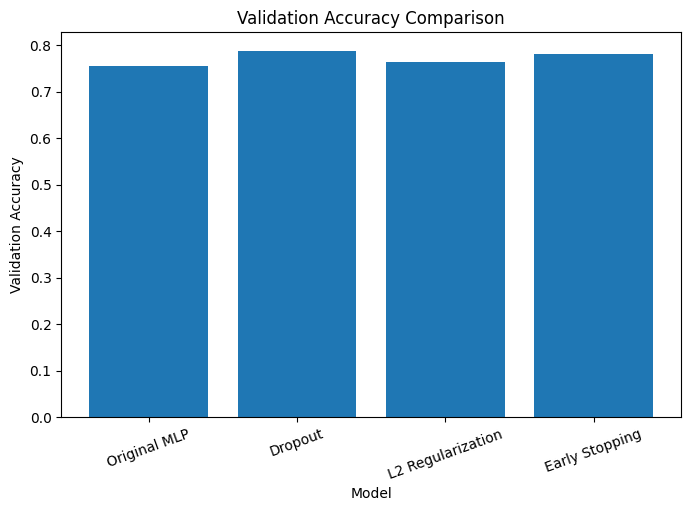

In [96]:
# Compare validation accuracy visually
plt.figure(figsize=(8, 5))

plt.bar(
    comparison['Model'],
    comparison['Final Validation Accuracy']
)

plt.title('Validation Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.xticks(rotation=20)
plt.show()

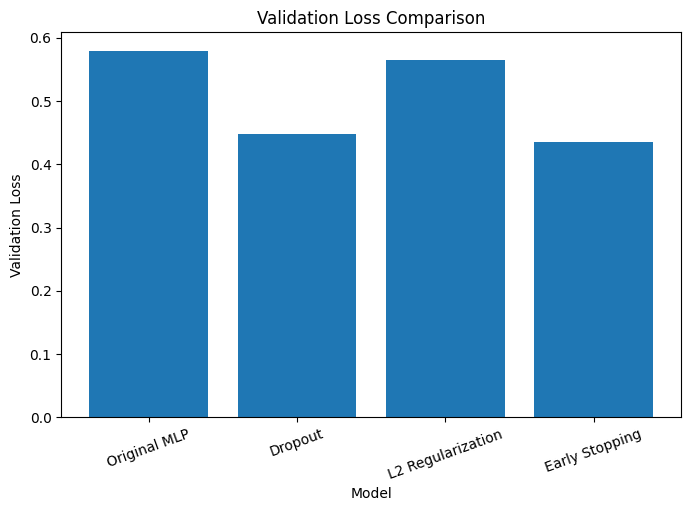

In [97]:
# plot validation loss comparison
plt.figure(figsize=(8, 5))

plt.bar(
    comparison['Model'],
    comparison['Final Validation Loss']
)

plt.title('Validation Loss Comparison')
plt.xlabel('Model')
plt.ylabel('Validation Loss')
plt.xticks(rotation=20)
plt.show()

In [98]:
# Calculate all evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predict probabilities
y_prob = early_model.predict(X_test_scaled).ravel()

# Convert probabilities to 0 or 1
y_pred = (y_prob >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("MLP Test Set Results")
print("--------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
MLP Test Set Results
--------------------
Accuracy : 0.7467532467532467
Precision: 0.6530612244897959
Recall   : 0.5925925925925926
F1 Score : 0.6213592233009708
ROC-AUC  : 0.8205555555555556


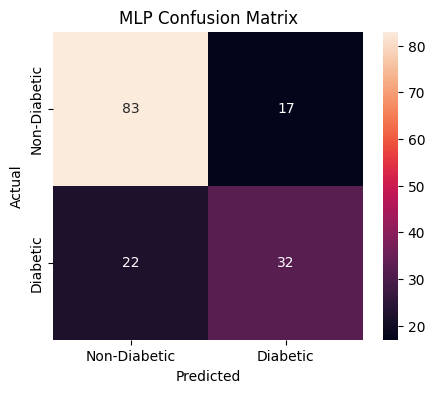

In [99]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [100]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 83
False Positives: 17
False Negatives: 22
True Positives : 32


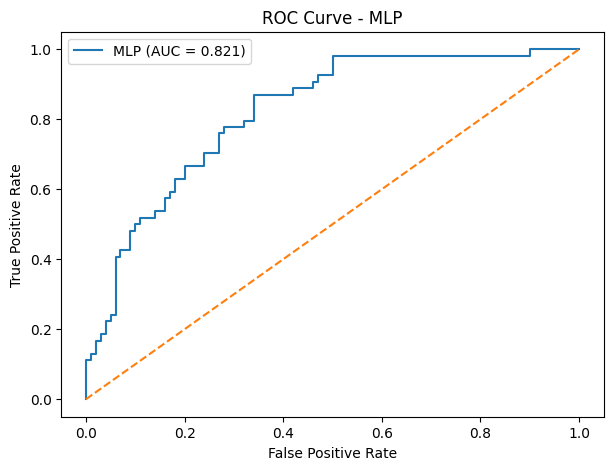

In [101]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"MLP (AUC = {roc_auc_value:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend()
plt.show()

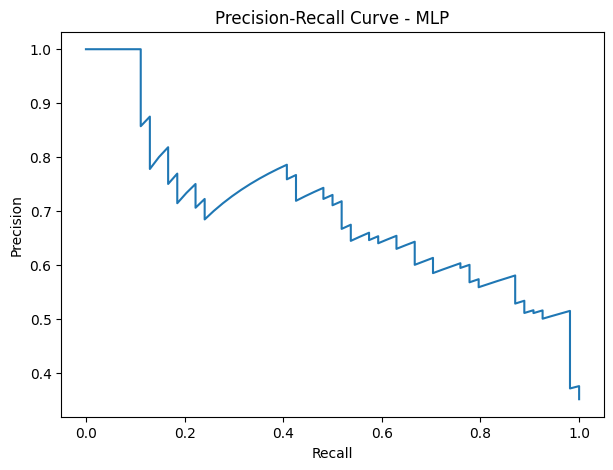

In [102]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - MLP")
plt.show()

Model Comparison and Selection

In [103]:
# Logistic Regression
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_pred_logistic = (y_prob_logistic >= 0.5).astype(int)

In [104]:
# KNN
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
y_pred_knn = (y_prob_knn >= 0.5).astype(int)

In [105]:
# SVM
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
y_pred_svm = (y_prob_svm >= 0.5).astype(int)

In [106]:
# Random Forest
y_prob_mlp = early_model.predict(X_test_scaled).ravel()
y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [107]:
# Calculate Accuracy, Precision, Recall, F1 and ROC-AUC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

models = {
    "Logistic Regression": (y_pred_logistic, y_prob_logistic),
    "KNN": (y_pred_knn, y_prob_knn),
    "SVM": (y_pred_svm, y_prob_svm),
    "Random Forest": (y_pred_rf, y_prob_rf),
    "MLP": (y_pred_mlp, y_prob_mlp)
}

results = []

for name, (pred, prob) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.688312,0.565217,0.481481,0.520000,0.809630
1,KNN,0.740260,0.634615,0.611111,0.622642,0.783148
2,SVM,0.733766,0.651163,0.518519,0.577320,0.799444
3,Random Forest,0.727273,0.630435,0.537037,0.580000,0.827222
4,MLP,0.746753,0.653061,0.592593,0.621359,0.820556


In [108]:
# Find the highest value for each metric
print("Highest Accuracy:")
print(comparison_df.loc[comparison_df["Accuracy"].idxmax()])

print("\nHighest Precision:")
print(comparison_df.loc[comparison_df["Precision"].idxmax()])

print("\nHighest Recall:")
print(comparison_df.loc[comparison_df["Recall"].idxmax()])

print("\nHighest F1:")
print(comparison_df.loc[comparison_df["F1"].idxmax()])

print("\nHighest ROC-AUC:")
print(comparison_df.loc[comparison_df["ROC-AUC"].idxmax()])

Highest Accuracy:
Model             MLP
Accuracy     0.746753
Precision    0.653061
Recall       0.592593
F1           0.621359
ROC-AUC      0.820556
Name: 4, dtype: object

Highest Precision:
Model             MLP
Accuracy     0.746753
Precision    0.653061
Recall       0.592593
F1           0.621359
ROC-AUC      0.820556
Name: 4, dtype: object

Highest Recall:
Model             KNN
Accuracy      0.74026
Precision    0.634615
Recall       0.611111
F1           0.622642
ROC-AUC      0.783148
Name: 1, dtype: object

Highest F1:
Model             KNN
Accuracy      0.74026
Precision    0.634615
Recall       0.611111
F1           0.622642
ROC-AUC      0.783148
Name: 1, dtype: object

Highest ROC-AUC:
Model        Random Forest
Accuracy          0.727273
Precision         0.630435
Recall            0.537037
F1                    0.58
ROC-AUC           0.827222
Name: 3, dtype: object


In [109]:
# Compare False Negatives
from sklearn.metrics import confusion_matrix

fn_results = []

for name, (pred, prob) in models.items():

    cm = confusion_matrix(y_test, pred)

    tn, fp, fn, tp = cm.ravel()

    fn_results.append({
        "Model": name,
        "True Negative": tn,
        "False Positive": fp,
        "False Negative": fn,
        "True Positive": tp
    })

confusion_df = pd.DataFrame(fn_results)

confusion_df

,Model,True Negative,False Positive,False Negative,True Positive
0,Logistic Regression,80,20,28,26
1,KNN,81,19,21,33
2,SVM,85,15,26,28
3,Random Forest,83,17,25,29
4,MLP,83,17,22,32


In [110]:
# Find the model with the fewest False Negatives
fewest_fn = confusion_df.loc[
    confusion_df["False Negative"].idxmin()
]

print("Model with fewest False Negatives:")
print(fewest_fn)

Model with fewest False Negatives:
Model             KNN
True Negative      81
False Positive     19
False Negative     21
True Positive      33
Name: 1, dtype: object


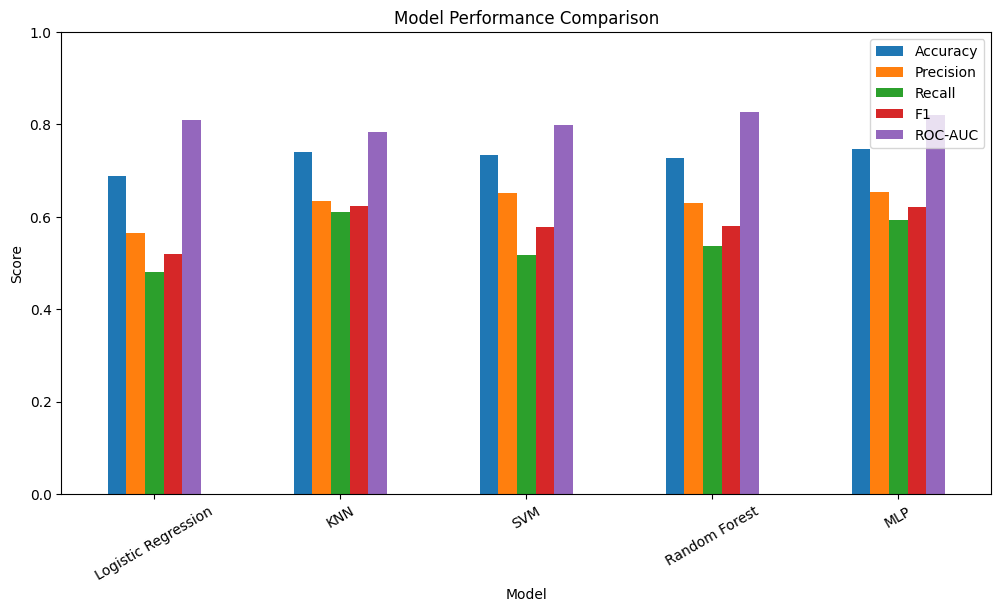

In [111]:
# Visual comparison of the models
import matplotlib.pyplot as plt

comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend()
plt.show()

In [112]:
# Which model achieved the highest recall?
highest_recall = comparison_df.loc[
    comparison_df["Recall"].idxmax()
]

print(
    "Highest Recall Model:",
    highest_recall["Model"]
)

print(
    "Recall:",
    highest_recall["Recall"]
)

Highest Recall Model: KNN
Recall: 0.6111111111111112


In [113]:
# Which model achieved the highest ROC-AUC?
highest_auc = comparison_df.loc[
    comparison_df["ROC-AUC"].idxmax()
]

print(
    "Highest ROC-AUC Model:",
    highest_auc["Model"]
)

print(
    "ROC-AUC:",
    highest_auc["ROC-AUC"]
)

Highest ROC-AUC Model: Random Forest
ROC-AUC: 0.8272222222222222


In [114]:
# Which model produced the fewest false negatives?
fewest_fn = confusion_df.loc[
    confusion_df["False Negative"].idxmin()
]

print("Model:", fewest_fn["Model"])
print("False Negatives:", fewest_fn["False Negative"])

Model: KNN
False Negatives: 21


In [115]:
# Is the MLP necessarily the best model?
# No, the MLP is not necessarily the best model just because the project is about an MLP.

In [116]:
# Final model selection
# Based on the current experimental comparison, KNN is the current candidate for deployment because it achieved the highest accuracy (74.03%) and F1-score (62.26%), tied with MLP for the highest recall (61.11%),
# and produced the fewest false negatives (21, tied with MLP). Random Forest achieved the highest ROC-AUC (82.72%), but its recall and false-negative count were lower than those of KNN. However, the final deployment
# model will be selected only after hyperparameter tuning and final evaluation on the unseen test set.

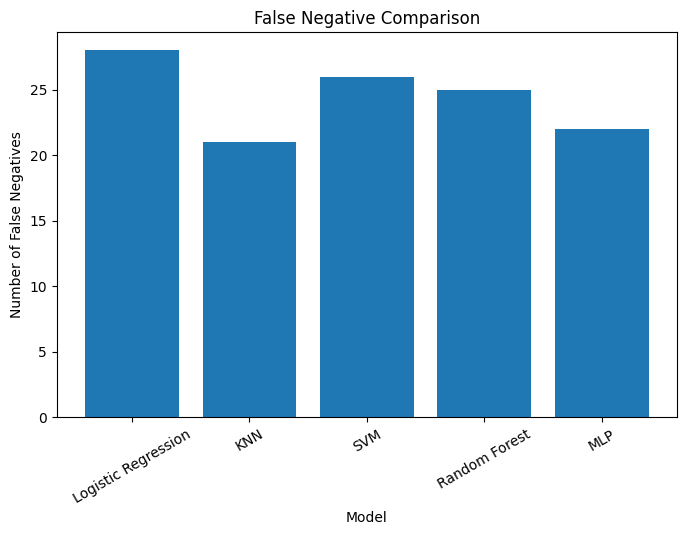

In [117]:
# One useful graph: False Negative Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    confusion_df["Model"],
    confusion_df["False Negative"]
)

plt.title("False Negative Comparison")
plt.xlabel("Model")
plt.ylabel("Number of False Negatives")
plt.xticks(rotation=30)

plt.show()

 Hyperparameter Tuning

In [118]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.0 MB/s eta 0:00:00


In [119]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [120]:
# Create the MLP model for tuning
def build_model(hp):

    model = Sequential()

    # Number of hidden layers
    num_layers = hp.Int(
        'num_layers',
        min_value=1,
        max_value=3,
        step=1
    )

    # Activation function
    activation = hp.Choice(
        'activation',
        values=['relu', 'tanh', 'sigmoid']
    )

    # Add hidden layers
    for i in range(num_layers):

        neurons = hp.Choice(
            f'neurons_{i}',
            values=[16, 32, 64, 128]
        )

        dropout = hp.Choice(
            f'dropout_{i}',
            values=[0.0, 0.2, 0.3, 0.5]
        )

        if i == 0:
            model.add(
                Dense(
                    neurons,
                    activation=activation,
                    input_shape=(X_train_scaled.shape[1],)
                )
            )
        else:
            model.add(
                Dense(
                    neurons,
                    activation=activation
                )
            )

        model.add(Dropout(dropout))

    # Output layer
    model.add(
        Dense(1, activation='sigmoid')
    )

    # Learning rate
    learning_rate = hp.Choice(
        'learning_rate',
        values=[0.001, 0.0005, 0.01]
    )

    # Optimizer
    optimizer_name = hp.Choice(
        'optimizer',
        values=['adam', 'rmsprop']
    )

    if optimizer_name == 'adam':
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )
    else:
        optimizer = tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [121]:
# Create the Random Search tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='diabetes_tuning',
    project_name='mlp_random_search',
    overwrite=True
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [122]:
tuner.search_space_summary()

Search space summary
Default search space size: 6
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'sigmoid'], 'ordered': False}
neurons_0 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64, 128], 'ordered': True}
dropout_0 (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.2, 0.3, 0.5], 'ordered': True}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0005, 0.01], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop'], 'ordered': False}


In [123]:
# Run the hyperparameter search
tuner.search(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Trial 20 Complete [00h 00m 09s]
val_accuracy: 0.8048780560493469

Best val_accuracy So Far: 0.8292682766914368
Total elapsed time: 00h 04m 00s


In [124]:
tuner.results_summary()

Results summary
Results in diabetes_tuning/mlp_random_search
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 18 summary
Hyperparameters:
num_layers: 3
activation: tanh
neurons_0: 32
dropout_0: 0.2
learning_rate: 0.001
optimizer: adam
neurons_1: 128
dropout_1: 0.2
neurons_2: 32
dropout_2: 0.0
Score: 0.8292682766914368

Trial 03 summary
Hyperparameters:
num_layers: 1
activation: tanh
neurons_0: 16
dropout_0: 0.2
learning_rate: 0.001
optimizer: rmsprop
neurons_1: 16
dropout_1: 0.0
neurons_2: 64
dropout_2: 0.5
Score: 0.8211382031440735

Trial 04 summary
Hyperparameters:
num_layers: 1
activation: relu
neurons_0: 128
dropout_0: 0.5
learning_rate: 0.0005
optimizer: adam
neurons_1: 64
dropout_1: 0.5
neurons_2: 16
dropout_2: 0.3
Score: 0.8211382031440735

Trial 05 summary
Hyperparameters:
num_layers: 3
activation: relu
neurons_0: 16
dropout_0: 0.0
learning_rate: 0.01
optimizer: rmsprop
neurons_1: 16
dropout_1: 0.2
neurons_2: 64
dropout_2: 0.3
Score: 0.8211382031440

In [125]:
# Get the best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters")
print("--------------------")

print("Number of Hidden Layers:",
      best_hp.get('num_layers'))

print("Activation:",
      best_hp.get('activation'))

print("Learning Rate:",
      best_hp.get('learning_rate'))

print("Optimizer:",
      best_hp.get('optimizer'))

Best Hyperparameters
--------------------
Number of Hidden Layers: 3
Activation: tanh
Learning Rate: 0.001
Optimizer: adam


In [126]:
# For the neurons and dropout,
for i in range(best_hp.get('num_layers')):

    print(
        f"Layer {i+1} Neurons:",
        best_hp.get(f'neurons_{i}')
    )

    print(
        f"Layer {i+1} Dropout:",
        best_hp.get(f'dropout_{i}')
    )

Layer 1 Neurons: 32
Layer 1 Dropout: 0.2
Layer 2 Neurons: 128
Layer 2 Dropout: 0.2
Layer 3 Neurons: 32
Layer 3 Dropout: 0.0


In [127]:
# Get the best tuned model
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [128]:
batch_sizes = [16, 32, 64]

batch_results = []

for batch in batch_sizes:

    model = tuner.hypermodel.build(best_hp)

    history_temp = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=batch,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    best_val_accuracy = max(
        history_temp.history['val_accuracy']
    )

    batch_results.append({
        'Batch Size': batch,
        'Best Validation Accuracy': best_val_accuracy
    })

batch_results_df = pd.DataFrame(batch_results)

batch_results_df

,Batch Size,Best Validation Accuracy
0,16,0.821138
1,32,0.813008
2,64,0.829268


In [129]:
best_batch = batch_results_df.loc[
    batch_results_df['Best Validation Accuracy'].idxmax(),
    'Batch Size'
]

print("Best Batch Size:", best_batch)

Best Batch Size: 64


In [130]:
final_mlp = tuner.hypermodel.build(best_hp)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

final_history = final_mlp.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=int(best_batch),   # this will be 16
    callbacks=[early_stopping],
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.6986 - loss: 0.5817 - val_accuracy: 0.7642 - val_loss: 0.4816
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7597 - loss: 0.4938 - val_accuracy: 0.7642 - val_loss: 0.4670
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7719 - loss: 0.4751 - val_accuracy: 0.7805 - val_loss: 0.4487
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7760 - loss: 0.4579 - val_accuracy: 0.7805 - val_loss: 0.4406
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7678 - loss: 0.4524 - val_accuracy: 0.7886 - val_loss: 0.4371
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7800 - loss: 0.4637 - val_accuracy: 0.8130 - val_loss: 0.4360
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7821 - loss: 0.4633 - val_accuracy: 0.8049 - val_loss: 0.4406
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7719 - loss: 0.4618 - val_accuracy: 0.7967 - val_loss:

In [131]:
print("Epochs actually completed:",
      len(final_history.history['loss']))

Epochs actually completed: 16


In [132]:
# Evaluate the tuned MLP on the test set
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Test predictions
y_prob_final = final_mlp.predict(X_test_scaled).ravel()

y_pred_final = (y_prob_final >= 0.5).astype(int)

# Metrics
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)
roc_auc = roc_auc_score(y_test, y_prob_final)

print("Final Tuned MLP Results")
print("-----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Final Tuned MLP Results
-----------------------
Accuracy : 0.7142857142857143
Precision: 0.6
Recall   : 0.5555555555555556
F1 Score : 0.5769230769230769
ROC-AUC  : 0.8133333333333334


In [133]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

print(cm)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

[[80 20]
 [24 30]]
True Negatives : 80
False Positives: 20
False Negatives: 24
True Positives : 30


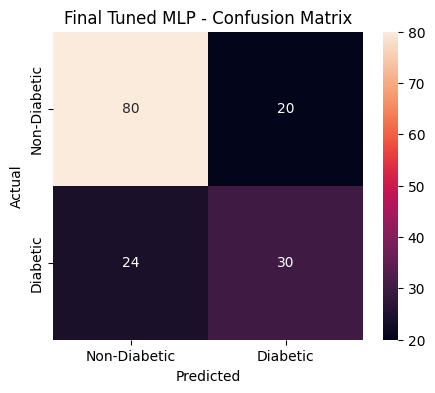

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title("Final Tuned MLP - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

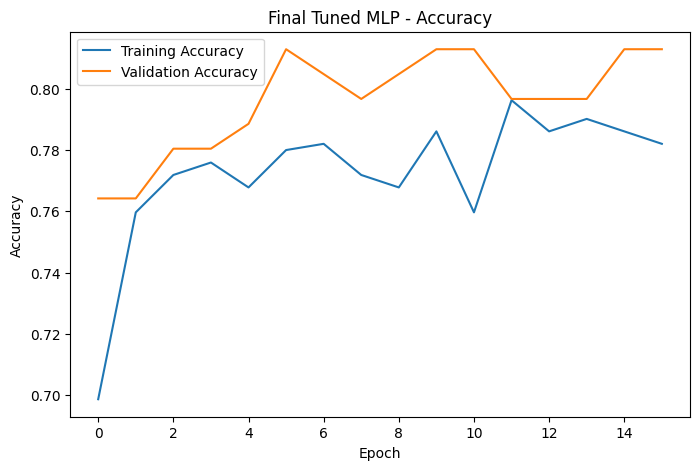

In [135]:
# Learning Curves
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    final_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Tuned MLP - Accuracy")
plt.legend()
plt.show()

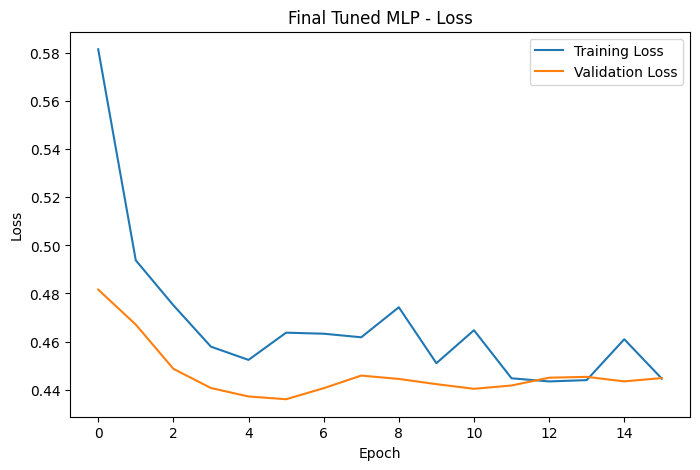

In [136]:
# Loss
plt.figure(figsize=(8, 5))

plt.plot(
    final_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    final_history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Tuned MLP - Loss")
plt.legend()
plt.show()

In [137]:
# Display the best hyperparameters
print("Best Hyperparameters")
print("--------------------")

print("Number of Hidden Layers:",
      best_hp.get('num_layers'))

print("Activation:",
      best_hp.get('activation'))

print("Learning Rate:",
      best_hp.get('learning_rate'))

print("Optimizer:",
      best_hp.get('optimizer'))

for i in range(best_hp.get('num_layers')):
    print(
        f"Layer {i+1} Neurons:",
        best_hp.get(f'neurons_{i}')
    )

    print(
        f"Layer {i+1} Dropout:",
        best_hp.get(f'dropout_{i}')
    )

print("Best Batch Size:", best_batch)

Best Hyperparameters
--------------------
Number of Hidden Layers: 3
Activation: tanh
Learning Rate: 0.001
Optimizer: adam
Layer 1 Neurons: 32
Layer 1 Dropout: 0.2
Layer 2 Neurons: 128
Layer 2 Dropout: 0.2
Layer 3 Neurons: 32
Layer 3 Dropout: 0.0
Best Batch Size: 64


In [138]:
# Save the final tuned model
final_mlp.save("diabetes_mlp.keras")

In [139]:
import os

print("Model saved:", os.path.exists("diabetes_mlp.keras"))

Model saved: True


In [140]:
# Final tuned MLP results table
final_results = pd.DataFrame({
    "Model": ["Final Tuned MLP"],
    "Accuracy": [accuracy_score(y_test, y_pred_final)],
    "Precision": [precision_score(y_test, y_pred_final)],
    "Recall": [recall_score(y_test, y_pred_final)],
    "F1": [f1_score(y_test, y_pred_final)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob_final)]
})

final_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Final Tuned MLP,0.714286,0.6,0.555556,0.576923,0.813333


In [141]:
# Select the best MLP configuration
print("Best MLP Configuration")
print("----------------------")

print("Hidden Layers:",
      best_hp.get('num_layers'))

print("Activation:",
      best_hp.get('activation'))

print("Learning Rate:",
      best_hp.get('learning_rate'))

print("Optimizer:",
      best_hp.get('optimizer'))

for i in range(best_hp.get('num_layers')):
    print(
        f"Layer {i+1} Neurons:",
        best_hp.get(f'neurons_{i}')
    )

    print(
        f"Layer {i+1} Dropout:",
        best_hp.get(f'dropout_{i}')
    )

print("Batch Size:", best_batch)

Best MLP Configuration
----------------------
Hidden Layers: 3
Activation: tanh
Learning Rate: 0.001
Optimizer: adam
Layer 1 Neurons: 32
Layer 1 Dropout: 0.2
Layer 2 Neurons: 128
Layer 2 Dropout: 0.2
Layer 3 Neurons: 32
Layer 3 Dropout: 0.0
Batch Size: 64


In [142]:
# Retrain the final model
final_mlp = tuner.hypermodel.build(best_hp)
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

final_history = final_mlp.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=int(best_batch),
    callbacks=[early_stopping],
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6293 - loss: 0.6574 - val_accuracy: 0.7154 - val_loss: 0.5589
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7332 - loss: 0.5258 - val_accuracy: 0.7317 - val_loss: 0.5044
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7495 - loss: 0.4976 - val_accuracy: 0.7561 - val_loss: 0.4686
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7536 - loss: 0.4863 - val_accuracy: 0.7886 - val_loss: 0.4533
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7862 - loss: 0.4722 - val_accuracy: 0.7724 - val_loss: 0.4526
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7760 - loss: 0.4684 - val_accuracy: 0.7724 - val_loss: 0.4591
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7760 - loss: 0.4606 - val_accuracy: 0.7805 - val_loss: 0.4580
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7699 - loss: 0.4545 - val_accuracy: 0.8130 - val_loss:

In [143]:
# Evaluate on the unseen test set
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predict probability
y_prob_final = final_mlp.predict(X_test_scaled).ravel()

# Convert probability to class
y_pred_final = (y_prob_final >= 0.5).astype(int)

# Calculate metrics
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_roc_auc = roc_auc_score(y_test, y_prob_final)

print("Final MLP Test Results")
print("----------------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_roc_auc)

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Final MLP Test Results
----------------------
Accuracy : 0.7077922077922078
Precision: 0.5957446808510638
Recall   : 0.5185185185185185
F1 Score : 0.5544554455445545
ROC-AUC  : 0.8157407407407408


In [144]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

print(cm)

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

[[81 19]
 [26 28]]
True Negatives : 81
False Positives: 19
False Negatives: 26
True Positives : 28


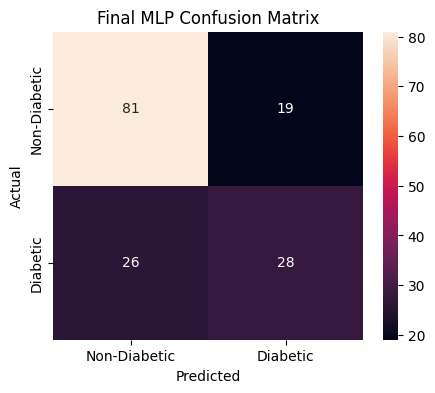

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Non-Diabetic', 'Diabetic'],
    yticklabels=['Non-Diabetic', 'Diabetic']
)

plt.title("Final MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [146]:
# Compare final MLP against baseline models
final_comparison = comparison_df.copy()

final_mlp_result = pd.DataFrame({
    "Model": ["Final Tuned MLP"],
    "Accuracy": [final_accuracy],
    "Precision": [final_precision],
    "Recall": [final_recall],
    "F1": [final_f1],
    "ROC-AUC": [final_roc_auc]
})

final_comparison = pd.concat(
    [final_comparison, final_mlp_result],
    ignore_index=True
)

final_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.688312,0.565217,0.481481,0.520000,0.809630
1,KNN,0.740260,0.634615,0.611111,0.622642,0.783148
2,SVM,0.733766,0.651163,0.518519,0.577320,0.799444
3,Random Forest,0.727273,0.630435,0.537037,0.580000,0.827222
4,MLP,0.746753,0.653061,0.592593,0.621359,0.820556
5,Final Tuned MLP,0.707792,0.595745,0.518519,0.554455,0.815741


In [147]:
# Compare false negatives
final_predictions = {
    "Logistic Regression": y_pred_logistic,
    "KNN": y_pred_knn,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "MLP": y_pred_mlp,
    "Final Tuned MLP": y_pred_final
}

fn_results = []

for name, pred in final_predictions.items():

    cm_temp = confusion_matrix(y_test, pred)

    tn_temp, fp_temp, fn_temp, tp_temp = cm_temp.ravel()

    fn_results.append({
        "Model": name,
        "False Negatives": fn_temp
    })

fn_comparison = pd.DataFrame(fn_results)

fn_comparison

,Model,False Negatives
0,Logistic Regression,28
1,KNN,21
2,SVM,26
3,Random Forest,25
4,MLP,22
5,Final Tuned MLP,26


In [148]:
final_mlp.save("diabetes_mlp.keras")

import joblib
joblib.dump(scaler, "scaler.pkl")

print("Final model and scaler saved successfully.")

Final model and scaler saved successfully.


In [149]:
import os

print("Model saved:", os.path.exists("diabetes_mlp.keras"))

Model saved: True


In [150]:
# install Streamlit and ngrok
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 70.3 MB/s eta 0:00:00


In [151]:
# Create the Streamlit application
%%writefile app.py
import streamlit as st
import tensorflow as tf
import joblib
import numpy as np

# --------------------------------------------------
# PAGE CONFIGURATION
# --------------------------------------------------

st.set_page_config(
    page_title="Diabetes Prediction",
    page_icon="🩺",
    layout="centered"
)

# --------------------------------------------------
# CUSTOM CSS DESIGN
# --------------------------------------------------

st.markdown("""
<style>

    /* Main background */
    .stApp {
        background: linear-gradient(135deg, #e0f7fa 0%, #e8eaf6 50%, #fce4ec 100%);
    }

    /* Main container */
    .block-container {
        max-width: 900px;
        padding-top: 2rem;
        padding-bottom: 3rem;
    }

    /* Title */
    .main-title {
        text-align: center;
        font-size: 42px;
        font-weight: 800;
        color: #172554;
        margin-bottom: 5px;
    }

    /* Subtitle */
    .subtitle {
        text-align: center;
        font-size: 18px;
        color: #475569;
        margin-bottom: 30px;
    }

    /* Information box */
    .info-box {
        background: rgba(255, 255, 255, 0.75);
        padding: 18px;
        border-radius: 15px;
        border-left: 6px solid #2563eb;
        margin-bottom: 25px;
        box-shadow: 0px 5px 20px rgba(0,0,0,0.08);
    }

    /* Section heading */
    .section-title {
        font-size: 23px;
        font-weight: 700;
        color: #172554;
        margin-top: 15px;
        margin-bottom: 10px;
    }

    /* Input labels */
    label {
        font-weight: 600 !important;
        color: #334155 !important;
    }

    /* Input boxes */
    div[data-baseweb="input"] {
        border-radius: 10px;
    }

    /* Prediction button */
    .stButton > button {
        width: 100%;
        border-radius: 12px;
        height: 55px;
        font-size: 20px;
        font-weight: 700;
        background: linear-gradient(90deg, #2563eb, #7c3aed);
        color: white;
        border: none;
        box-shadow: 0px 6px 15px rgba(37, 99, 235, 0.3);
        transition: 0.3s;
    }

    .stButton > button:hover {
        transform: scale(1.02);
        box-shadow: 0px 8px 20px rgba(124, 58, 237, 0.35);
    }

    /* Result cards */
    .result-card {
        padding: 25px;
        border-radius: 18px;
        text-align: center;
        margin-top: 25px;
        box-shadow: 0px 8px 25px rgba(0,0,0,0.12);
    }

    .result-title {
        font-size: 30px;
        font-weight: 800;
        margin-bottom: 8px;
    }

    .probability {
        font-size: 22px;
        font-weight: 600;
    }

    /* Footer */
    .footer {
        text-align: center;
        margin-top: 40px;
        color: #64748b;
        font-size: 14px;
    }

</style>
""", unsafe_allow_html=True)


# --------------------------------------------------
# LOAD MODEL AND SCALER
# --------------------------------------------------

model = tf.keras.models.load_model("diabetes_mlp.keras")
scaler = joblib.load("scaler.pkl")


# --------------------------------------------------
# TITLE
# --------------------------------------------------

st.markdown(
    '<div class="main-title">🩺 Diabetes Prediction System</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">Multilayer Perceptron based Diabetes Risk Prediction</div>',
    unsafe_allow_html=True
)


# --------------------------------------------------
# INFORMATION BOX
# --------------------------------------------------

st.markdown("""
<div class="info-box">
<b>📋 About this application</b><br>
Enter the patient's health information below.
The trained Machine Learning model will predict whether the patient
is likely to be diabetic or non-diabetic.
</div>
""", unsafe_allow_html=True)


# --------------------------------------------------
# INPUT SECTION
# --------------------------------------------------

st.markdown(
    '<div class="section-title">👤 Patient Information</div>',
    unsafe_allow_html=True
)

col1, col2 = st.columns(2)

with col1:

    pregnancies = st.number_input(
        "🤰 Pregnancies",
        min_value=0,
        max_value=20,
        value=1,
        step=1
    )

    glucose = st.number_input(
        "🩸 Glucose",
        min_value=0.0,
        max_value=300.0,
        value=120.0,
        step=1.0
    )

    blood_pressure = st.number_input(
        "💓 Blood Pressure",
        min_value=0.0,
        max_value=200.0,
        value=70.0,
        step=1.0
    )

    skin_thickness = st.number_input(
        "📏 Skin Thickness",
        min_value=0.0,
        max_value=100.0,
        value=20.0,
        step=1.0
    )

with col2:

    insulin = st.number_input(
        "💉 Insulin",
        min_value=0.0,
        max_value=900.0,
        value=125.0,
        step=1.0
    )

    bmi = st.number_input(
        "⚖️ BMI",
        min_value=0.0,
        max_value=70.0,
        value=30.0,
        step=0.1
    )

    diabetes_pedigree = st.number_input(
        "🧬 Diabetes Pedigree Function",
        min_value=0.0,
        max_value=3.0,
        value=0.5,
        step=0.01
    )

    age = st.number_input(
        "🎂 Age",
        min_value=1,
        max_value=120,
        value=30,
        step=1
    )


# --------------------------------------------------
# PREDICTION BUTTON
# --------------------------------------------------

st.markdown("<br>", unsafe_allow_html=True)

predict_button = st.button("🔍 Predict Diabetes")


# --------------------------------------------------
# PREDICTION
# --------------------------------------------------

if predict_button:

    # ----------------------------------------------
    # Replace invalid zero values with training
    # medians
    # ----------------------------------------------

    if glucose == 0:
        glucose = 117.0

    if blood_pressure == 0:
        blood_pressure = 72.0

    if skin_thickness == 0:
        skin_thickness = 29.0

    if insulin == 0:
        insulin = 125.0

    if bmi == 0:
        bmi = 32.3


    # ----------------------------------------------
    # Feature Engineering
    # ----------------------------------------------

    glucose_bmi = glucose * bmi
    glucose_age = glucose * age
    bmi_age = bmi * age

    insulin_log = np.log1p(insulin)

    pedigree_log = np.log1p(diabetes_pedigree)


    # ----------------------------------------------
    # Create input in EXACT training order
    # ----------------------------------------------

    input_data = np.array([[
        pregnancies,
        glucose,
        blood_pressure,
        skin_thickness,
        insulin,
        bmi,
        diabetes_pedigree,
        age,
        glucose_bmi,
        glucose_age,
        bmi_age,
        insulin_log,
        pedigree_log
    ]])


    # ----------------------------------------------
    # Scale input
    # ----------------------------------------------

    input_scaled = scaler.transform(input_data)


    # ----------------------------------------------
    # Prediction
    # ----------------------------------------------

    probability = model.predict(input_scaled, verbose=0)[0][0]

    prediction = 1 if probability >= 0.5 else 0

    # --------------------------------------------------
    # Display Result
    # --------------------------------------------------

    if prediction == 1:

        confidence = probability * 100

        st.error("⚠️ Diabetic")
        st.write(f"### Prediction Probability: {confidence:.2f}%")
        st.warning("The model predicts a higher likelihood of diabetes.")

    else:

        confidence = (1 - probability) * 100

        st.success("✅ Non-Diabetic")
        st.write(f"### Prediction Probability: {confidence:.2f}%")
        st.info("The model predicts a lower likelihood of diabetes.")


# --------------------------------------------------
# FOOTER
# --------------------------------------------------

st.markdown("""
<div class="footer">
    🎓 College Minor Project | Predicting Diabetes with Multilayer Perceptrons
    <br>
    <small>For educational purposes only — not a medical diagnosis.</small>
</div>
""", unsafe_allow_html=True)


Writing app.py


In [152]:
!pkill -f streamlit

In [153]:
!streamlit run app.py &>/content/logs.txt &

In [154]:
from pyngrok import ngrok
ngrok.set_auth_token("3JSeoxygFH4JvSmcBkxm48LgECW_3654YFJMoJdERLz7SxR1t")
ngrok.kill()

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://joystick-sandstone-likewise.ngrok-free.dev" -> "http://localhost:8501"


In [155]:
test_input = np.array([[
    6,       # Pregnancies
    180,     # Glucose
    90,      # BloodPressure
    35,      # SkinThickness
    200,     # Insulin
    35.0,    # BMI
    0.8,     # DiabetesPedigreeFunction
    50,      # Age
    180 * 35,
    180 * 50,
    35 * 50,
    np.log1p(200),
    np.log1p(0.8)
]])

test_scaled = scaler.transform(test_input)

probability = final_mlp.predict(test_scaled, verbose=0)[0][0]

prediction = 1 if probability >= 0.5 else 0

print("Prediction:", "Diabetic" if prediction == 1 else "Non-Diabetic")
print("Probability:", probability * 100)

Prediction: Diabetic
Probability: 91.03574


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


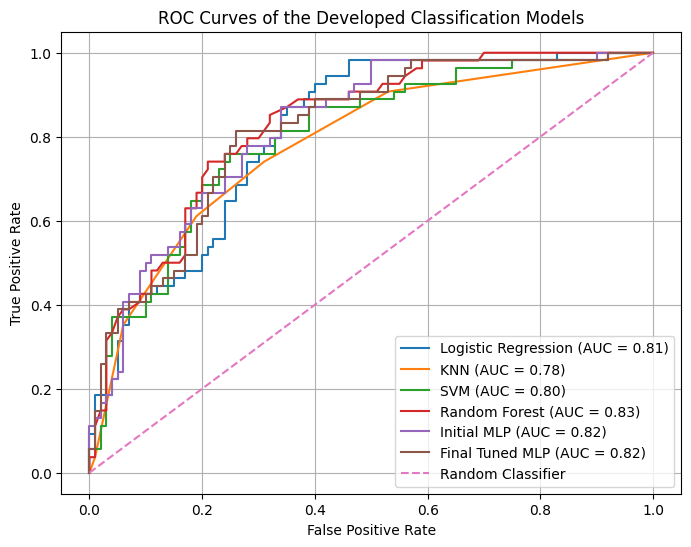

In [160]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_logistic)
auc_lr = roc_auc_score(y_test, y_prob_logistic)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')

# Initial MLP
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)
plt.plot(fpr_mlp, tpr_mlp, label=f'Initial MLP (AUC = {auc_mlp:.2f})')

# Final Tuned MLP
fpr_final, tpr_final, _ = roc_curve(y_test, y_prob_final)
auc_final = roc_auc_score(y_test, y_prob_final)
plt.plot(fpr_final, tpr_final,
         label=f'Final Tuned MLP (AUC = {auc_final:.2f})')

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves of the Developed Classification Models')
plt.legend()
plt.grid(True)

plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

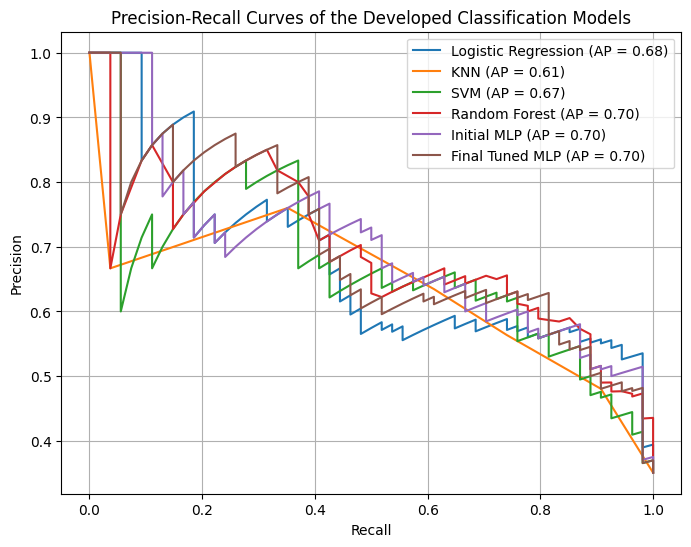

In [161]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_logistic)
ap_lr = average_precision_score(y_test, y_prob_logistic)
plt.plot(recall_lr, precision_lr,
         label=f'Logistic Regression (AP = {ap_lr:.2f})')

# KNN
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_prob_knn)
ap_knn = average_precision_score(y_test, y_prob_knn)
plt.plot(recall_knn, precision_knn,
         label=f'KNN (AP = {ap_knn:.2f})')

# SVM
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm)
ap_svm = average_precision_score(y_test, y_prob_svm)
plt.plot(recall_svm, precision_svm,
         label=f'SVM (AP = {ap_svm:.2f})')

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf,
         label=f'Random Forest (AP = {ap_rf:.2f})')

# Initial MLP
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_prob_mlp)
ap_mlp = average_precision_score(y_test, y_prob_mlp)
plt.plot(recall_mlp, precision_mlp,
         label=f'Initial MLP (AP = {ap_mlp:.2f})')

# Final Tuned MLP
precision_final, recall_final, _ = precision_recall_curve(
    y_test, y_prob_final
)
ap_final = average_precision_score(y_test, y_prob_final)
plt.plot(recall_final, precision_final,
         label=f'Final Tuned MLP (AP = {ap_final:.2f})')

# Labels
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves of the Developed Classification Models')
plt.legend()
plt.grid(True)

# Save the figure
plt.savefig(
    'precision_recall_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()